<a href="https://colab.research.google.com/github/sean838432/TdAI/blob/separate_operational_cycle_models/model_training/TdAI_v2_3_Deterministic_BETA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''
This script first loads in HRRR 12z previous day forecast soundings from 2020 to 2026 from April to mid-November.

It then uses a gradient boosted decision tree algorithm to correct NBM biases. The ML algorithm is set up as follows:

VERSION ARCHITECTURE:
1) We train only on the 21z data. This provided big improvements because now we are only focusing on the time of maximum mixing and lowest RH
2) No re-distribution of the dataset is done (no random removal of quiet days and no sky/temp/RH/LPW filtering of the dataset)
3) Training data from 2020-2024 & 2026 is used. 2025 is the validation dataset
4) A smaller number of trees and smaller max depth of trees is used to account for the smaller dataset (resulting from only using 21z data). This prevents overfitting
5) An operational validation framework has been added to assess model performance if TdAI was run only under set weather conditions (i.e. when a bust was most likely)

    FEATURE VARIABLES:
        NBM Temperature (C)
        NBM RH (%)
        NBM Sky (%)
        NBM Mixing Height (100s of ft AGL)
        NBM Wind Speed (kts)
        NBM Wind Direction (deg)
        HRRR RH at all levels (%)
        HRRR PWAT
        HRRR 1000mb-850mb Lapse Rate (C/km)
        HRRR 850mb-500mb Lapse Rate (C/km)
        Time of year

    OUTCOME VARIABLE:
        Td error from the 12z NBM forecast

    WEIGHTING SCHEME:
        Td error 3-4 F: Weight of 2
        Td error >= 5 F: Weight of 5

    BUST PROPORTIONALITY SCHEME:
        None
'''

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
!pip install metpy
from metpy.plots import SkewT
from metpy.units import units
import math
import joblib
import shap
import sklearn

print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 18.5 MB/s eta 0:00:00
NumPy: 2.0.2
Scikit-learn: 1.6.1


# **Functions**

In [ ]:
def seed_everything(seed=42):
    # 1. Set Python's built-in random seed
    random.seed(seed)
    # 2. Set Numpy's seed (Crucial for your jittering/noise)
    np.random.seed(seed)
    # 3. Set environment variable for any OS-level randomness
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Random state locked at {seed}")

seed_everything(42)


def calculate_lpw_vectorized(df, all_levels):
    """
    Calculates Integrated Water Vapor (LPW) in millimeters (mm) across all
    specified pressure levels simultaneously using high-speed vectorized NumPy operations.
    Designed explicitly for input columns stored natively in Celsius.
    """
    g = 9.80665
    rho_w = 1000.0

    # Pre-allocate specific humidity arrays for each level across all rows
    q_matrix = []

    for lvl in all_levels:
        p = float(lvl)
        dpt_col = f'dpt_{lvl}'  # Ambient temp (t_col) is not mathematically required for LPW depth

        # --- AUGUST-ROCHE-MAGNUS FORMULATION (https://en.wikipedia.org/wiki/Clausius%E2%80%93Clapeyron_relation#Meteorology_and_climatology) ---
        # Takes dpt in Celsius
        e = 6.1094 * np.exp((17.625 * (df[dpt_col])) / (df[dpt_col] + 243.04))

        # Calculate mixing ratio (w) and specific humidity (q) https://glossary.ametsoc.org/wiki/specific-humidity/
        w = 0.622 * e / (p - e)
        q = w / (1.0 + w)

        q_matrix.append(q.values)

    # Shape of matrix: (num_levels, num_rows)
    q_matrix = np.array(q_matrix)

    # Initialize the integration output array
    lpw_total = np.zeros(len(df))

    # Hydrostatic integration layer-by-layer
    for i in range(len(all_levels) - 1):
        p_high = float(all_levels[i])   # Higher pressure (e.g., 1000 hPa)
        p_low = float(all_levels[i+1])  # Lower pressure (e.g., 925 hPa)

        # Pressure differential converted to Pascals (1 hPa = 100 Pa)
        dp = (p_high - p_low) * 100.0

        # Average specific humidity across the bounded layer
        q_avg = (q_matrix[i] + q_matrix[i+1]) / 2.0

        # Hydrostatic integration equation mapping to mm depth
        lpw_total += (q_avg * dp) / (g * rho_w) * 1000.0

    return lpw_total


def calculate_lapse_rate_vectorized(df, p_bottom, p_top):
  """
  Calculates the vertical temperature lapse rate (°C/km) between any two pressure
  levels dynamically using the Hypsometric Equation to determine layer thickness.

  Parameters:
  -----------
  df : pandas.DataFrame
      The pivoted HRRR DataFrame containing columns in 't_LEVEL' format (Celsius).
  p_bottom : int
      The pressure level at the bottom of the layer (e.g., 1000).
  p_top : int
      The pressure level at the top of the layer (e.g., 850).

  Returns:
  --------
  pandas.Series or np.nan
      A vectorized series representing the lapse rate in °C/km.
  """
  t_bottom_col = f't_{p_bottom}'
  t_top_col = f't_{p_top}'

  # 1. Enforce safety validation check for missing levels
  if t_bottom_col not in df.columns or t_top_col not in df.columns:
      return np.nan

  # 2. Extract ambient temperatures at the boundaries (assumed already in Celsius)
  t_bottom = df[t_bottom_col]
  t_top = df[t_top_col]

  # 3. Calculate raw temperature difference (Bottom - Top)
  # Positive = temperature cooling with height
  delta_t = t_bottom - t_top

  # 4. DYNAMIC GEOPOTENTIAL THICKNESS (The Hypsometric Equation)
  # Rd = 287.05 J/(kg*K) [Gas constant for dry air]
  # g  = 9.80665 m/s^2  [Standard gravitational acceleration]
  # Convert mean layer temperature to Kelvin
  t_mean_k = ((t_bottom + t_top) / 2.0) + 273.15

  # Calculate layer thickness in meters, then divide by 1000.0 for kilometers (dz_km)
  dz_meters = (287.05 * t_mean_k / 9.80665) * np.log(float(p_bottom) / float(p_top))
  dz_km = dz_meters / 1000.0

  # 5. Compute the lapse rate
  lapse_rate = delta_t / dz_km

  return lapse_rate

✅ Random state locked at 42


# **Compile Training Dataset**

In [ ]:
# --- CONFIGURATION ---
import os
import pandas as pd
import numpy as np

base_path = "/content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/"
STATIONS = ['CAR']

# 📅 Define dataset date thresholds (YYYY-MM-DD)
START_DATE = '2020-12-02' # To restrict dataset to HRRRv4 only
END_DATE = '2026-12-31'

# Define the 4 target operational cycles mapping inputs and target Day Offsets
CYCLES = [
    {
        'name': '12z_f09',
        'hrrr_file': '12z_f09_Soundings.parquet',
        'nbm_file': '13z.csv',
        'target_day_offset': 0  # Day 1 (Valid Date == Init Date)
    },
    {
        'name': '12z_f33',
        'hrrr_file': '12z_f33_Soundings.parquet',
        'nbm_file': '13z.csv',
        'target_day_offset': 1  # Day 2 (Valid Date == Init Date + 1)
    },
    {
        'name': '00z_f21',
        'hrrr_file': '00z_f21_Soundings.parquet',
        'nbm_file': '01z.csv',
        'target_day_offset': 0  # Day 1 (Valid Date == Init Date)
    },
    {
        'name': '00z_f45',
        'hrrr_file': '00z_f45_Soundings.parquet',
        'nbm_file': '01z.csv',
        'target_day_offset': 1  # Day 2 (Valid Date == Init Date + 1)
    }
]

# Dictionary to collect compiled dataframes separated by cycle
cycle_master_dfs = {cycle['name']: [] for cycle in CYCLES}

print(f"🚀 Starting Master Compilation for {len(STATIONS)} stations across {len(CYCLES)} distinct models...")

for station in STATIONS:
    print(f"\n────────────────── Processing Station: K{station} ──────────────────")

    # --- 1. LOAD ASOS GROUND TRUTH (Only needs to be done once per station) ---
    asos_path = os.path.join(base_path, f"ASOS_Data/K{station}_2020_to_2026_asos.csv")
    if not os.path.exists(asos_path):
        print(f"⚠️ Missing ASOS file for K{station}. Skipping this station entirely.")
        continue

    print(f"   Loading ASOS ground truth...")
    asos_df = pd.read_csv(asos_path)
    asos_df['valid_time'] = pd.to_datetime(asos_df['valid_time']).dt.round('h')
    asos_df = asos_df[['valid_time', 'ASOS Dewpoint (F)']].dropna()

    # --- 2. LOOP THROUGH EACH PREDICTION CYCLE ---
    for cycle in CYCLES:
        c_name = cycle['name']
        print(f"\n   ⚙️ Structuring Cycle: {c_name}...")

        hrrr_path = os.path.join(base_path, f"HRRR_Data/K{station}_{cycle['hrrr_file']}")
        nbm_path = os.path.join(base_path, f"NBM_Data/NBM_Master_Data_K{station}_{cycle['nbm_file']}")

        if not (os.path.exists(hrrr_path) and os.path.exists(nbm_path)):
            print(f"      ⚠️ Missing HRRR or NBM file for {c_name}. Skipping cycle.")
            continue

        try:
            # --- A. LOAD & FILTER NBM BASELINE USING DATE OFFSETS ---
            nbm_df = pd.read_csv(nbm_path)
            nbm_df['valid_time'] = pd.to_datetime(nbm_df['NBM Forecast Valid (UTC)'])
            nbm_df['init_time'] = pd.to_datetime(nbm_df['NBM Initialization Time (UTC)'])

            # Extract just the date components to calculate the Day Offset (0 for Day 1, 1 for Day 2)
            nbm_df['day_offset'] = (nbm_df['valid_time'].dt.normalize() - nbm_df['init_time'].dt.normalize()).dt.days

            # Strictly isolate the correct day's forecast based on our cycle definition
            nbm_df = nbm_df[nbm_df['day_offset'] == cycle['target_day_offset']].copy()

            if nbm_df.empty:
                print(f"      ⚠️ No NBM data found matching Day Offset {cycle['target_day_offset']}. Skipping.")
                continue

            # --- B. LOAD & PIVOT HRRR SOUNDING SAMPLES ---
            hrrr_long = pd.read_parquet(hrrr_path)
            hrrr_long['valid_time'] = pd.to_datetime(hrrr_long['valid_time'])

            # Vectorized pivot mapping 3D profile to 2D features
            hrrr_pivoted = hrrr_long.pivot(
                index='valid_time',
                columns='isobaricInhPa',
                values=['t', 'dpt']
            )

            # Flatten MultiIndex columns
            hrrr_pivoted.columns = [f"{v}_{int(p)}" for v, p in hrrr_pivoted.columns]
            hrrr_pivoted = hrrr_pivoted.reset_index()

            # --- C. METEOROLOGICAL CONVERSIONS ---
            thermal_cols = [c for c in hrrr_pivoted.columns if c.startswith('t_') or c.startswith('dpt_')]
            hrrr_pivoted[thermal_cols] = hrrr_pivoted[thermal_cols] - 273.15

            all_levels = sorted(
                [int(col.split('_')[1]) for col in hrrr_pivoted.columns if col.startswith('t_')],
                reverse=True
            )

            hrrr_pivoted['hrrr_lpw (mm)'] = calculate_lpw_vectorized(hrrr_pivoted, all_levels)

            rh_features_dict = {}
            for lvl in all_levels:
                t_col = f't_{lvl}'
                dpt_col = f'dpt_{lvl}'
                if t_col in hrrr_pivoted.columns and dpt_col in hrrr_pivoted.columns:
                    es = np.exp((17.625 * hrrr_pivoted[t_col]) / (243.04 + hrrr_pivoted[t_col]))
                    e = np.exp((17.625 * hrrr_pivoted[dpt_col]) / (243.04 + hrrr_pivoted[dpt_col]))
                    rh_features_dict[f'rh_{lvl}'] = np.clip(100 * (e / es), 0.0, 100.0)

            new_features_df = pd.DataFrame(rh_features_dict, index=hrrr_pivoted.index)
            hrrr_pivoted = pd.concat([hrrr_pivoted, new_features_df], axis=1)

            hrrr_pivoted['1000mb-700mb Lapse Rate (C/km)'] = calculate_lapse_rate_vectorized(hrrr_pivoted, 1000, 700)
            hrrr_pivoted['700mb-500mb Lapse Rate (C/km)'] = calculate_lapse_rate_vectorized(hrrr_pivoted, 700, 500)

            # --- D. THE NBM-ASOS-HRRR MERGE ---
            station_df = pd.merge(nbm_df, asos_df, on='valid_time', how='inner')
            station_df = pd.merge(station_df, hrrr_pivoted, on='valid_time', how='inner')

            station_df['Target Error (F)'] = station_df['NBM Dewpoint (F)'] - station_df['ASOS Dewpoint (F)']

            # --- E. CALCULATE AND ADD NBM RH ---
            station_df = station_df[pd.to_datetime(station_df['valid_time']).dt.hour == 21].copy()

            nbm_tc = (station_df['NBM Temperature (F)'] - 32) * (5.0 / 9.0)
            nbm_tdc = (station_df['NBM Dewpoint (F)'] - 32) * (5.0 / 9.0)
            nbm_es = np.exp((17.625 * nbm_tc) / (243.04 + nbm_tc))
            nbm_e = np.exp((17.625 * nbm_tdc) / (243.04 + nbm_tdc))
            station_df['NBM RH (%)'] = np.clip(100 * (nbm_e / nbm_es), 0.0, 100.0)

            # --- F. ELIMINATE UNNECESSARY COLUMNS ---
            columns_to_drop = [
                'NBM Initialization Time (UTC)',
                'NBM Forecast Valid (UTC)',
                'ASOS Dewpoint (F)',
                'NBM Dewpoint (F)',
                'init_time',
                'day_offset'
            ]
            raw_sounding_thermals = [c for c in station_df.columns if c.startswith('t_') or c.startswith('dpt_')]
            columns_to_drop.extend(raw_sounding_thermals)

            station_df = station_df.drop(columns=columns_to_drop, errors='ignore')
            station_df = station_df.dropna()

            print(f"      ✅ Generated {len(station_df)} valid tactical samples for {c_name}.")

            # Append strictly to this cycle's list
            cycle_master_dfs[c_name].append(station_df)

        except Exception as e:
            print(f"      ❌ Failed to process cycle {c_name} for K{station}: {e}")
            continue


# --- 3. EXPORT 4 INDIVIDUAL DATASETS ---

# Define your strict column hierarchy
TARGET_COLUMN_ORDER = [
    'Target Error (F)',
    'NBM Temperature (F)',
    'NBM Cloud Cover (%)',
    'NBM Mixing Height (100s ft AGL)',
    'NBM Wind Speed (kts)',
    'NBM Wind Direction (deg)',
    'NBM RH (%)',
    'hrrr_lpw (mm)',
    '1000mb-700mb Lapse Rate (C/km)',
    '700mb-500mb Lapse Rate (C/km)',
    'rh_1000', 'rh_975', 'rh_950', 'rh_925', 'rh_900', 'rh_875', 'rh_850',
    'rh_825', 'rh_800', 'rh_775', 'rh_750', 'rh_725', 'rh_700', 'rh_675',
    'rh_650', 'rh_625', 'rh_600', 'rh_575', 'rh_550', 'rh_525', 'rh_500',
    'sin_season',
    'cos_season'
]

print("\n🔗 Generating Individual Training Datasets...")

for cycle_name, df_list in cycle_master_dfs.items():
    if not df_list:
        print(f"   ⚠️ No data successfully compiled for {cycle_name}.")
        continue

    master_train_df = pd.concat(df_list, ignore_index=True)

    # Add shared engineering features
    day_of_year_series = master_train_df['valid_time'].dt.dayofyear
    master_train_df['sin_season'] = np.sin(2 * np.pi * day_of_year_series / 365.25)
    master_train_df['cos_season'] = np.cos(2 * np.pi * day_of_year_series / 365.25)

    # Set index and ensure datetime format
    master_train_df = master_train_df.set_index('valid_time')
    master_train_df.index = pd.to_datetime(master_train_df.index)

    # 📅 APPLY DATE THRESHOLD FILTER
    original_len = len(master_train_df)
    master_train_df = master_train_df.sort_index().loc[START_DATE:END_DATE]
    print(f"   📅 Applied date filter ({START_DATE} to {END_DATE}): {original_len} -> {len(master_train_df)} samples remaining.")

    # 🚀 ENFORCE STRICT COLUMN ORDER
    # Filter to only columns that actually exist in the DataFrame to prevent KeyErrors
    existing_cols = [col for col in TARGET_COLUMN_ORDER if col in master_train_df.columns]
    master_train_df = master_train_df[existing_cols]

    output_filename = f"TdAI_Training_Data_{cycle_name}.csv"
    output_dir = os.path.join(base_path, 'Training_Dataset')
    os.makedirs(output_dir, exist_ok=True)
    output_full_path = os.path.join(output_dir, output_filename)

    master_train_df.to_csv(output_full_path, index=True)
    print(f"   💾 Saved {cycle_name} Dataset: {len(master_train_df)} total samples -> {output_filename}")

print("\n✨ ALL DONE! Matrix configurations successfully generated.")

🚀 Starting Master Compilation for 1 stations across 4 distinct models...

────────────────── Processing Station: KCAR ──────────────────
   Loading ASOS ground truth...

   ⚙️ Structuring Cycle: 12z_f09...
      ✅ Generated 1555 valid tactical samples for 12z_f09.

   ⚙️ Structuring Cycle: 12z_f33...
      ✅ Generated 1545 valid tactical samples for 12z_f33.

   ⚙️ Structuring Cycle: 00z_f21...
      ✅ Generated 1536 valid tactical samples for 00z_f21.

   ⚙️ Structuring Cycle: 00z_f45...
      ✅ Generated 1372 valid tactical samples for 00z_f45.

🔗 Generating Individual Training Datasets...
   📅 Applied date filter (2020-12-02 to 2026-12-31): 1555 -> 1383 samples remaining.
   💾 Saved 12z_f09 Dataset: 1383 total samples -> TdAI_Training_Data_12z_f09.csv
   📅 Applied date filter (2020-12-02 to 2026-12-31): 1545 -> 1372 samples remaining.
   💾 Saved 12z_f33 Dataset: 1372 total samples -> TdAI_Training_Data_12z_f33.csv
   📅 Applied date filter (2020-12-02 to 2026-12-31): 1536 -> 1372 sam

# **Analyze The Td Bust Distribution**

In [ ]:
# =========================================================================
# 📊 ANALYZE EXTREME DEWPOINT BUST DISTRIBUTION (PER OPERATIONAL CYCLE)
# =========================================================================

print("\n" + "="*75)
print("📊 EXTREME NBM DEWPOINT BUST ANALYSIS (≥ 5°F ABSOLUTE ERROR)")
print("="*75)

# Track global counts across all cycles
global_samples = 0
global_moist_count = 0
global_dry_count = 0

# Loop through each individual cycle stored in cycle_master_dfs
for cycle_name, df_list in cycle_master_dfs.items():
    if not df_list:
        print(f"\n⚠️ Cycle {cycle_name}: No samples compiled.")
        continue

    cycle_df = pd.concat(df_list, ignore_index=True)
    total_samples = len(cycle_df)

    if total_samples > 0:
        # Calculate positive errors (NBM significantly moister than ASOS)
        moist_busts = cycle_df[cycle_df['Target Error (F)'] >= 5.0]
        # Calculate negative errors (NBM significantly drier than ASOS)
        dry_busts = cycle_df[cycle_df['Target Error (F)'] <= -5.0]
        # Total absolute errors >= 5°F
        total_busts = cycle_df[cycle_df['Target Error (F)'].abs() >= 5.0]

        pct_moist = (len(moist_busts) / total_samples) * 100
        pct_dry = (len(dry_busts) / total_samples) * 100
        pct_total = (len(total_busts) / total_samples) * 100

        # Accumulate for global summary
        global_samples += total_samples
        global_moist_count += len(moist_busts)
        global_dry_count += len(dry_busts)

        print(f"\n⚙️ Cycle: {cycle_name} (Total Samples: {total_samples})")
        print(f"   🔹 Moist Busts (NBM Too Wet ≥ +5°F): {len(moist_busts):4d} samples ({pct_moist:5.2f}%)")
        print(f"   🔸 Dry Busts   (NBM Too Dry ≤ -5°F): {len(dry_busts):4d} samples ({pct_dry:5.2f}%)")
        print(f"   🔺 Total Extreme Busts (|Error| ≥ 5°F): {len(total_busts):4d} samples ({pct_total:5.2f}%)")
        print("──────────────────────────────────────────────────────────────────")

# -------------------------------------------------------------------------
# GLOBAL ALL-CYCLE SUMMARY
# -------------------------------------------------------------------------
if global_samples > 0:
    global_total_busts = global_moist_count + global_dry_count
    g_pct_moist = (global_moist_count / global_samples) * 100
    g_pct_dry = (global_dry_count / global_samples) * 100
    g_pct_total = (global_total_busts / global_samples) * 100

    print("\n🌐 OVERALL COMBINED DATASET SUMMARY (ALL CYCLES)")
    print(f"   🔹 Global Moist Busts (NBM Too Wet): {global_moist_count:4d} / {global_samples} ({g_pct_moist:5.2f}%)")
    print(f"   🔸 Global Dry Busts   (NBM Too Dry): {global_dry_count:4d} / {global_samples} ({g_pct_dry:5.2f}%)")
    print(f"   🔺 Global Total Extreme Busts      : {global_total_busts:4d} / {global_samples} ({g_pct_total:5.2f}%)")
    print("="*75)
else:
    print("\n❌ No valid samples found across any cycle to perform bust analysis.")


📊 EXTREME NBM DEWPOINT BUST ANALYSIS (≥ 5°F ABSOLUTE ERROR)

⚙️ Cycle: 12z_f09 (Total Samples: 1555)
   🔹 Moist Busts (NBM Too Wet ≥ +5°F):  105 samples ( 6.75%)
   🔸 Dry Busts   (NBM Too Dry ≤ -5°F):   60 samples ( 3.86%)
   🔺 Total Extreme Busts (|Error| ≥ 5°F):  165 samples (10.61%)
──────────────────────────────────────────────────────────────────

⚙️ Cycle: 12z_f33 (Total Samples: 1545)
   🔹 Moist Busts (NBM Too Wet ≥ +5°F):  133 samples ( 8.61%)
   🔸 Dry Busts   (NBM Too Dry ≤ -5°F):   92 samples ( 5.95%)
   🔺 Total Extreme Busts (|Error| ≥ 5°F):  225 samples (14.56%)
──────────────────────────────────────────────────────────────────

⚙️ Cycle: 00z_f21 (Total Samples: 1536)
   🔹 Moist Busts (NBM Too Wet ≥ +5°F):  109 samples ( 7.10%)
   🔸 Dry Busts   (NBM Too Dry ≤ -5°F):   74 samples ( 4.82%)
   🔺 Total Extreme Busts (|Error| ≥ 5°F):  183 samples (11.91%)
──────────────────────────────────────────────────────────────────

⚙️ Cycle: 00z_f45 (Total Samples: 1372)
   🔹 Moist Busts

# **GBDT Model Training**

In [ ]:
# --- CONFIGURATION ---
base_path = "/content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/"
models_output_path = os.path.join(base_path, "Trained_TdAI_Models/")
os.makedirs(models_output_path, exist_ok=True)

# Define the 4 target operational cycles
CYCLE_NAMES = ['12z_f09', '12z_f33', '00z_f21', '00z_f45']

print("🚀 INITIALIZING MULTI-MODEL GBDT TRAINING PIPELINE")
print("=" * 70)

for c_name in CYCLE_NAMES:
    dataset_file = f"TdAI_Training_Data_{c_name}.csv"
    dataset_full_path = os.path.join(base_path, f"Training_Dataset/{dataset_file}")

    print(f"\n────────────────── Training Cycle Model: {c_name} ──────────────────")

    if not os.path.exists(dataset_full_path):
        print(f"⚠️ Dataset file missing: {dataset_file}. Skipping cycle.")
        continue

    # --- 1. LOAD & PREPARE DATASET ---
    df = pd.read_csv(dataset_full_path)

    if 'valid_time' in df.columns:
        df = df.set_index('valid_time')

    df.index = pd.to_datetime(df.index)

    # Separate X (Features) and y (Target Error)
    X = df.drop(columns=['Target Error (F)'], errors='ignore')
    y = df['Target Error (F)']

    # Save exact feature ordering for operational schema verification at runtime
    feature_order = X.columns.tolist()

    # --- 2. CHRONOLOGICAL TRAIN/TEST SPLIT (2025 ISOLATION) ---
    years = X.index.year
    is_test_year = (years == 2025)
    is_train_year = ~is_test_year

    X_train, y_train = X[is_train_year], y[is_train_year]
    X_test, y_test = X[is_test_year], y[is_test_year]

    print(f"   📊 Data Split Complete:")
    print(f"      • Training Set (2020-2024 + 2026) : {len(X_train)} samples")
    print(f"      • Validation Set (Strictly 2025)  : {len(X_test)} samples")

    # --- 3. MODEL INITIALIZATION & WEIGHTING ---
    gb_model = HistGradientBoostingRegressor(
        max_iter=400,
        learning_rate=0.03,
        max_depth=4,
        max_features=0.5,
        loss='absolute_error',
        random_state=42
    )

    # Weight large positive NBM moist busts higher during optimization
    sample_weights = np.where(y_train >= 5.0, 5.0, np.where(y_train >= 3.0, 2.0, 1.0))

    # --- 4. TRAIN MODEL ---
    print(f"   🏋️ Training GBDT ensemble for {c_name}...")
    gb_model.fit(X_train, y_train, sample_weight=sample_weights)

    # --- 5. GLOBAL TEST EVALUATION ---
    y_pred = gb_model.predict(X_test)
    global_mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"   📈 Global 2025 Validation Results:")
    print(f"      • Mean Absolute Error        : {global_mae:.2f}°F")
    print(f"      • Explained Variance (R²)    : {r2:.2f}")

    # --- 6. OPERATIONAL TACTICAL GATE VERIFICATION ---
    operational_gate = (
        (X_test['NBM RH (%)'] <= 60.0) &
        (X_test['NBM Cloud Cover (%)'] <= 60.0) &
        (X_test['hrrr_lpw (mm)'] <= 25.0)
    )

    X_test_active = X_test[operational_gate]
    y_test_active = y_test[operational_gate]

    if len(X_test_active) == 0:
        print("   ⚠️ Warning: Zero validation samples matched live operational criteria in 2025.")
    else:
        y_pred_active = gb_model.predict(X_test_active)
        tdai_active_mae = mean_absolute_error(y_test_active, y_pred_active)
        nbm_baseline_mae = np.abs(y_test_active).mean()
        mae_skill_score = (1.0 - (tdai_active_mae / nbm_baseline_mae)) * 100

        print(f"\n   🔥 LIVE FIRE WEATHER DOMAIN VERIFICATION (Active 2025 Windows Only):")
        print(f"      • Tactical Active Hours          : {len(X_test_active)} hours")
        print(f"      • Raw NBM Baseline MAE           : {nbm_baseline_mae:.2f}°F")
        print(f"      • TdAI Corrected MAE             : {tdai_active_mae:.2f}°F")
        print(f"      ───► 🚀 Tactical Skill Score     : {mae_skill_score:+.1f}% Error Reduction")

    # --- 7. EXPORT INDIVIDUAL MODEL WEIGHTS AND FEATURE SCHEMAS ---
    model_save_filename = f"tdai_deterministic_model_{c_name}.joblib"
    schema_save_filename = f"deterministic_model_feature_schema_{c_name}.joblib"

    model_save_path = os.path.join(models_output_path, model_save_filename)
    schema_save_path = os.path.join(models_output_path, schema_save_filename)

    joblib.dump(gb_model, model_save_path)
    joblib.dump(feature_order, schema_save_path)

    print(f"   💾 Model Artifacts Saved:")
    print(f"      • Model Weights -> {model_save_filename}")
    print(f"      • Feature Schema -> {schema_save_filename}")

print("\n" + "=" * 70)
print("✨ ALL MODEL TRAINING CYCLES COMPLETE!")

🚀 INITIALIZING MULTI-MODEL GBDT TRAINING PIPELINE

────────────────── Training Cycle Model: 12z_f09 ──────────────────
   📊 Data Split Complete:
      • Training Set (2020-2024 + 2026) : 1127 samples
      • Validation Set (Strictly 2025)  : 256 samples
   🏋️ Training GBDT ensemble for 12z_f09...
   📈 Global 2025 Validation Results:
      • Mean Absolute Error        : 1.87°F
      • Explained Variance (R²)    : 0.32

   🔥 LIVE FIRE WEATHER DOMAIN VERIFICATION (Active 2025 Windows Only):
      • Tactical Active Hours          : 111 hours
      • Raw NBM Baseline MAE           : 2.31°F
      • TdAI Corrected MAE             : 1.97°F
      ───► 🚀 Tactical Skill Score     : +14.8% Error Reduction
   💾 Model Artifacts Saved:
      • Model Weights -> tdai_deterministic_model_12z_f09.joblib
      • Feature Schema -> deterministic_model_feature_schema_12z_f09.joblib

────────────────── Training Cycle Model: 12z_f33 ──────────────────
   📊 Data Split Complete:
      • Training Set (2020-2024 +

# **Model Performance Analysis**

🚀 RUNNING MULTI-CYCLE MOIST BUST EVALUATION & VISUALIZATION PIPELINE
Dataset Full Path /content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/Training_Dataset/TdAI_Training_Data_12z_f09.csv
Model Full Path /content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/Trained_TdAI_Models/tdai_deterministic_model_12z_f09.joblib

────────────────── Analyzing Cycle: 12z_f09 ──────────────────


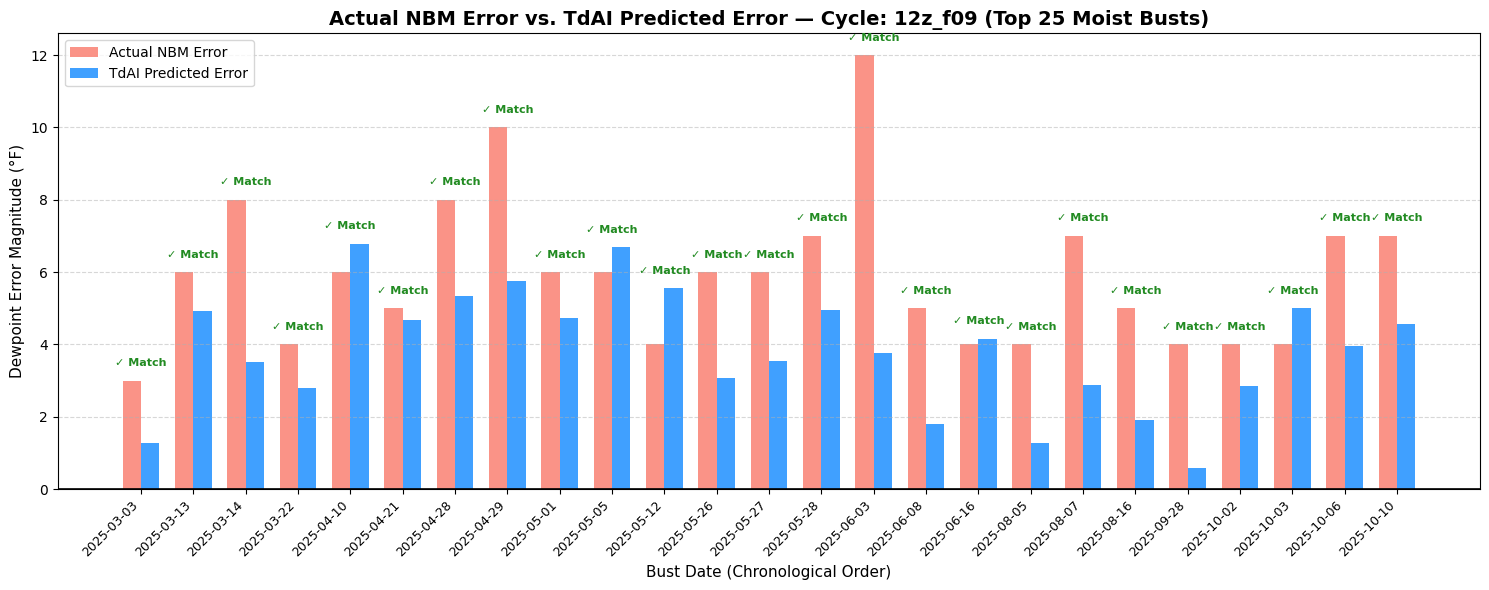

🏆 ACCUMULATED ERROR REPORT: 12z_f09 (TOP 25 MOIST BUST DAYS)
  (Constraints: Fire Weather Windows | Wrong-Direction Penalty Active)
Total Accumulated Raw NBM Error        : 148.0°F
Total Accumulated TdAI Constrained Error: 60.1°F
-----------------------------------------------------------------
🟢 Net Error REMOVED by TdAI             : 87.9°F
📉 Percent Error Reduction               : 59.4%
Dataset Full Path /content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/Training_Dataset/TdAI_Training_Data_12z_f33.csv
Model Full Path /content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/Trained_TdAI_Models/tdai_deterministic_model_12z_f33.joblib

────────────────── Analyzing Cycle: 12z_f33 ──────────────────


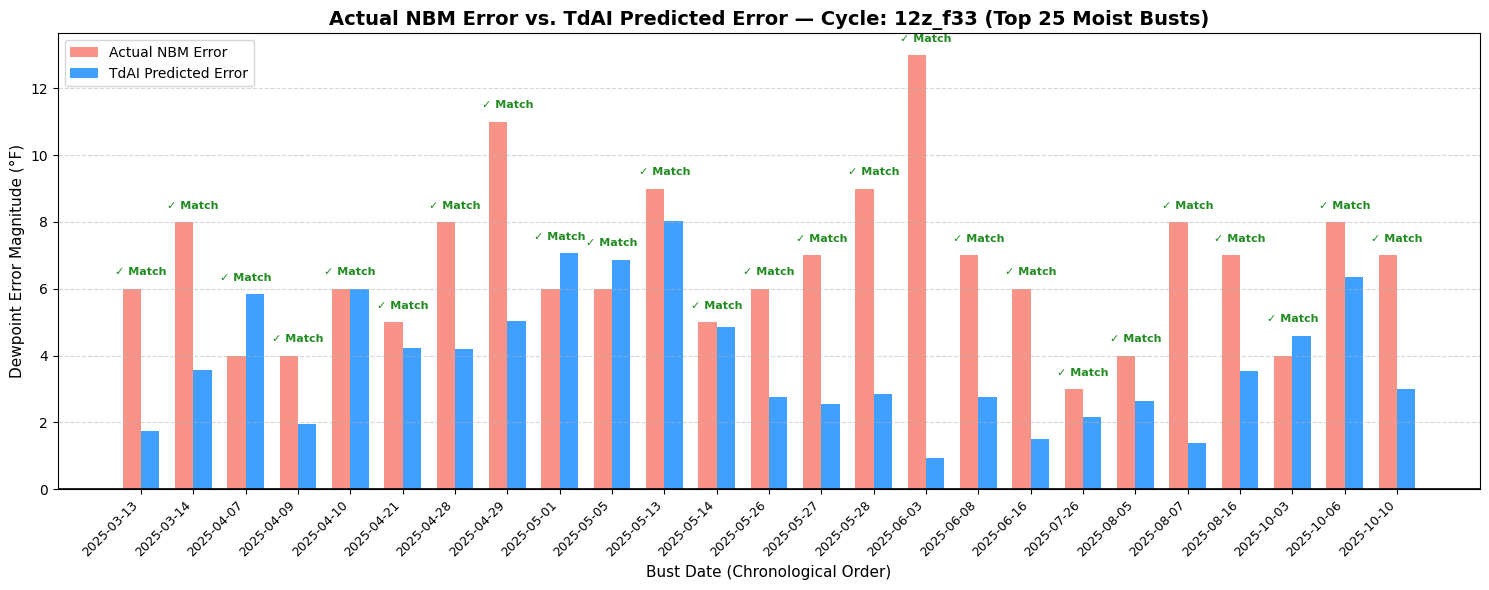

🏆 ACCUMULATED ERROR REPORT: 12z_f33 (TOP 25 MOIST BUST DAYS)
  (Constraints: Fire Weather Windows | Wrong-Direction Penalty Active)
Total Accumulated Raw NBM Error        : 167.0°F
Total Accumulated TdAI Constrained Error: 79.4°F
-----------------------------------------------------------------
🟢 Net Error REMOVED by TdAI             : 87.6°F
📉 Percent Error Reduction               : 52.5%
Dataset Full Path /content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/Training_Dataset/TdAI_Training_Data_00z_f21.csv
Model Full Path /content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/Trained_TdAI_Models/tdai_deterministic_model_00z_f21.joblib

────────────────── Analyzing Cycle: 00z_f21 ──────────────────


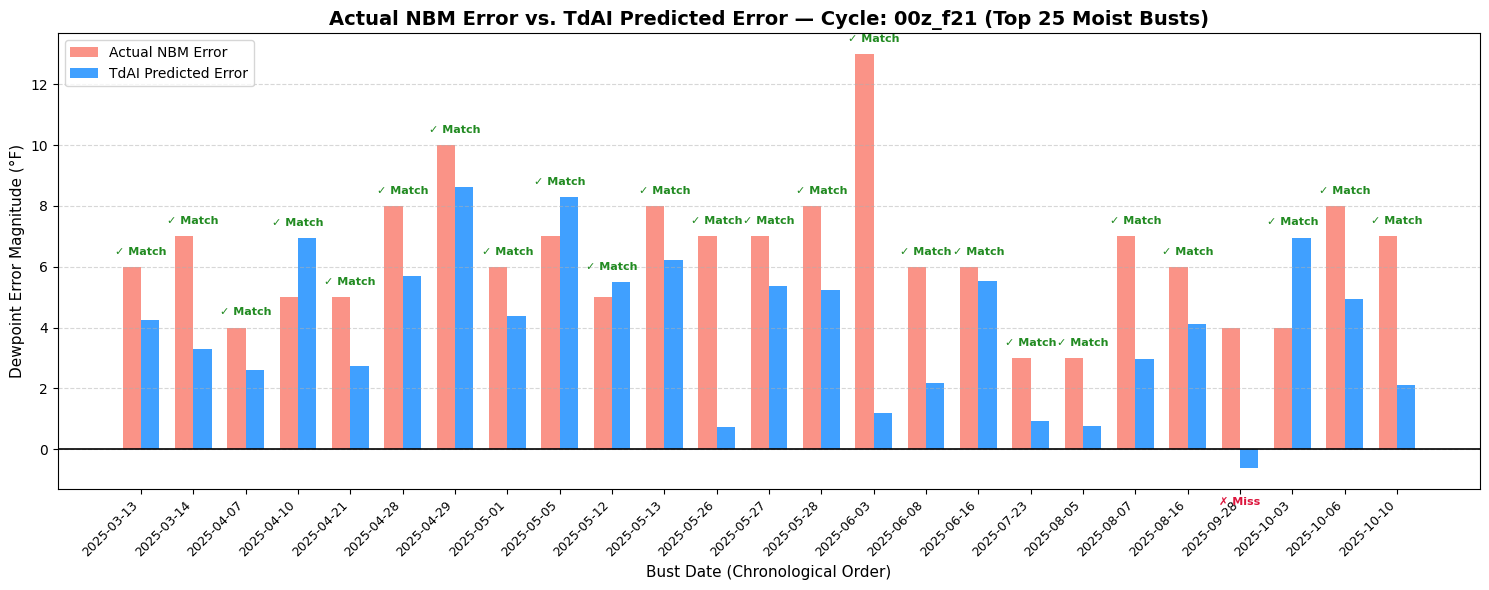

🏆 ACCUMULATED ERROR REPORT: 00z_f21 (TOP 25 MOIST BUST DAYS)
  (Constraints: Fire Weather Windows | Wrong-Direction Penalty Active)
Total Accumulated Raw NBM Error        : 160.0°F
Total Accumulated TdAI Constrained Error: 72.5°F
-----------------------------------------------------------------
🟢 Net Error REMOVED by TdAI             : 87.5°F
📉 Percent Error Reduction               : 54.7%
Dataset Full Path /content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/Training_Dataset/TdAI_Training_Data_00z_f45.csv
Model Full Path /content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/Trained_TdAI_Models/tdai_deterministic_model_00z_f45.joblib

────────────────── Analyzing Cycle: 00z_f45 ──────────────────


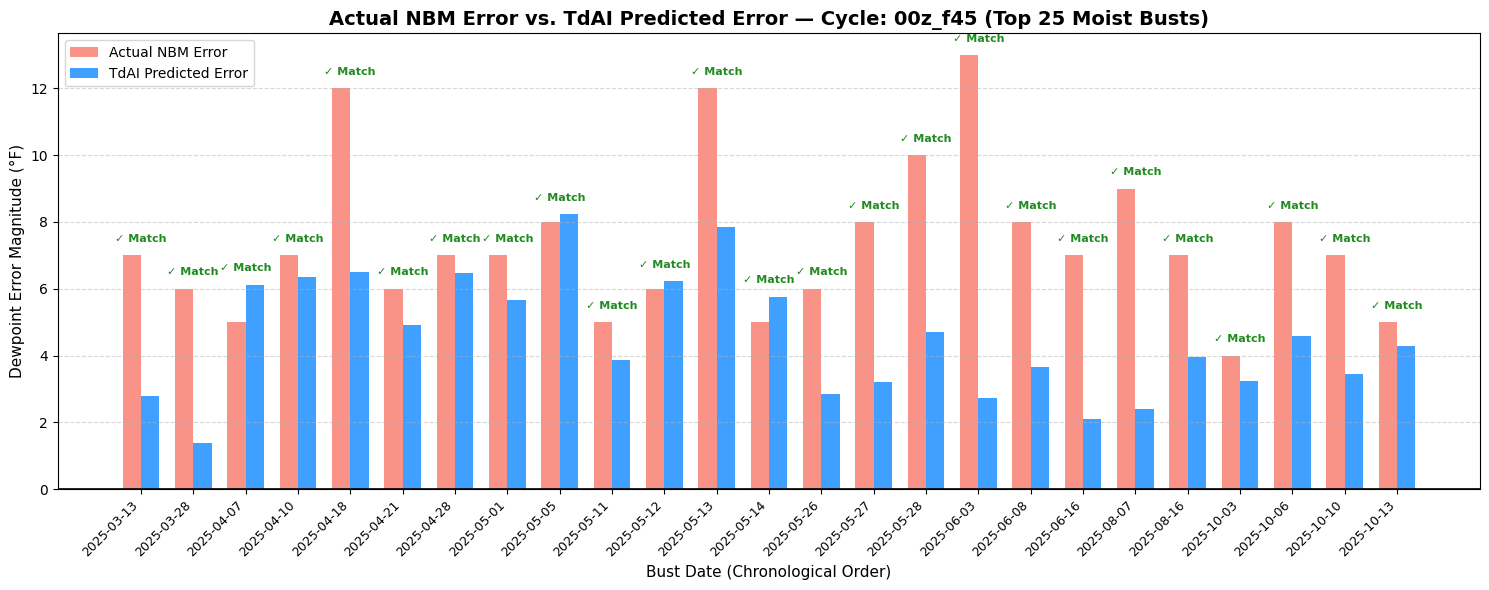

🏆 ACCUMULATED ERROR REPORT: 00z_f45 (TOP 25 MOIST BUST DAYS)
  (Constraints: Fire Weather Windows | Wrong-Direction Penalty Active)
Total Accumulated Raw NBM Error        : 185.0°F
Total Accumulated TdAI Constrained Error: 76.4°F
-----------------------------------------------------------------
🟢 Net Error REMOVED by TdAI             : 108.6°F
📉 Percent Error Reduction               : 58.7%

✨ ALL CYCLE EVALUATIONS COMPLETE!


In [ ]:
# --- CONFIGURATION ---
base_path = "/content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/"
models_output_path = os.path.join(base_path, "Trained_TdAI_Models/")

# Define the 4 target operational cycles
CYCLE_NAMES = ['12z_f09', '12z_f33', '00z_f21', '00z_f45']

print("🚀 RUNNING MULTI-CYCLE MOIST BUST EVALUATION & VISUALIZATION PIPELINE")
print("=" * 80)

for c_name in CYCLE_NAMES:
    dataset_file = f"TdAI_Training_Data_{c_name}.csv"
    model_file = f"tdai_deterministic_model_{c_name}.joblib"

    dataset_full_path = os.path.join(base_path, f"Training_Dataset/{dataset_file}")
    model_full_path = os.path.join(models_output_path, model_file)
    print("Dataset Full Path", dataset_full_path)
    print("Model Full Path", model_full_path)

    print(f"\n────────────────── Analyzing Cycle: {c_name} ──────────────────")

    # Check that both the compiled dataset and trained model exist
    if not (os.path.exists(dataset_full_path) and os.path.exists(model_full_path)):
        print(f"⚠️ Missing dataset ({dataset_file}) or trained model ({model_file}). Skipping cycle.")
        continue

    # --- 1. LOAD DATASET & TRAINED MODEL ---
    df = pd.read_csv(dataset_full_path)
    if 'valid_time' in df.columns:
        df = df.set_index('valid_time')
    df.index = pd.to_datetime(df.index)

    # Isolate 2025 validation set
    years = df.index.year
    is_test_year = (years == 2025)

    df_test = df[is_test_year].copy()

    if df_test.empty:
        print(f"⚠️ No 2025 validation samples found for cycle {c_name}. Skipping.")
        continue

    X_test = df_test.drop(columns=['Target Error (F)'], errors='ignore')
    y_test = df_test['Target Error (F)']

    # Load cycle model and generate predictions
    gb_model = joblib.load(model_full_path)
    y_pred = gb_model.predict(X_test)

    # --- 2. PREPARE RESULTS DATAFRAME ---
    results_df = pd.DataFrame(index=X_test.index)
    results_df['valid_time'] = pd.to_datetime(X_test.index)
    results_df['date'] = results_df['valid_time'].dt.date
    results_df['nbm_error_f'] = y_test.values
    results_df['model_pred_error_f'] = y_pred

    # Filter for active operational fire weather domain windows only
    operational_gate = (
        (X_test['NBM RH (%)'] <= 60.0) &
        (X_test['NBM Cloud Cover (%)'] <= 60.0) &
        (X_test['hrrr_lpw (mm)'] <= 25.0)
    ).values

    results_df = results_df[operational_gate].copy()

    if results_df.empty:
        print(f"⚠️ Zero 2025 test samples matched the operational fire weather criteria for {c_name}.")
        continue

    # --- 3. APPLY DIRECTIONAL PENALTY LOGIC (MOIST DAYS ONLY) ---
    moist_days_df = results_df[results_df['nbm_error_f'] > 0].copy()

    if moist_days_df.empty:
        print(f"⚠️ Zero moist bust days (NBM Error > 0) found for cycle {c_name}.")
        continue

    wrong_direction_mask = moist_days_df['model_pred_error_f'] < 0

    standard_residual = moist_days_df['nbm_error_f'] - moist_days_df['model_pred_error_f']
    penalty_residual = moist_days_df['nbm_error_f'].abs() + moist_days_df['model_pred_error_f'].abs()

    moist_days_df['final_constrained_residual'] = np.where(
        wrong_direction_mask,
        penalty_residual,
        standard_residual
    )

    # --- 4. ISOLATE THE TOP 25 DAILY "BUST DAYS" ---
    daily_summary = moist_days_df.groupby('date').agg({
        'nbm_error_f': lambda x: x.iloc[np.abs(x).argmax()],
        'model_pred_error_f': lambda x: x.iloc[np.abs(x).argmax()],
        'final_constrained_residual': lambda x: x.iloc[np.abs(x).argmax()]
    }).reset_index()

    num_busts = min(25, len(daily_summary))
    top_busts = daily_summary.sort_values(by='nbm_error_f', ascending=False).head(num_busts)
    top_busts = top_busts.sort_values(by='date')

    # --- 5. GENERATE COMPARISON CHART FOR THIS CYCLE ---
    plt.figure(figsize=(15, 6))
    x = np.arange(len(top_busts))
    width = 0.35

    plt.bar(x - width/2, top_busts['nbm_error_f'], width, label='Actual NBM Error', color='salmon', alpha=0.85)
    plt.bar(x + width/2, top_busts['model_pred_error_f'], width, label='TdAI Predicted Error', color='dodgerblue', alpha=0.85)

    plt.axhline(0, color='black', linewidth=1.2, linestyle='-')
    plt.xticks(x, top_busts['date'], rotation=45, ha='right', fontsize=9)
    plt.ylabel('Dewpoint Error Magnitude (°F)', fontsize=11)
    plt.xlabel('Bust Date (Chronological Order)', fontsize=11)
    plt.title(f'Actual NBM Error vs. TdAI Predicted Error — Cycle: {c_name} (Top {num_busts} Moist Busts)', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10, loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Directional Annotation Engine
    for i, row in enumerate(top_busts.itertuples()):
        same_direction = np.sign(row.nbm_error_f) == np.sign(row.model_pred_error_f)

        if same_direction:
            y_pos = max(row.nbm_error_f, row.model_pred_error_f) + 0.4
            plt.text(i, y_pos, '✓ Match', ha='center', color='forestgreen', fontweight='bold', fontsize=8)
        else:
            y_pos = row.model_pred_error_f - 1.2
            plt.text(i, y_pos, '✗ Miss', ha='center', color='crimson', fontweight='bold', fontsize=8)

    plt.tight_layout()
    plt.show()

    # --- 6. ACCUMULATED TOTALS & REPORT ---
    accumulated_raw_nbm_error = top_busts['nbm_error_f'].abs().sum()
    accumulated_tdai_error = top_busts['final_constrained_residual'].abs().sum()

    net_error_change = accumulated_raw_nbm_error - accumulated_tdai_error
    percent_change = (net_error_change / accumulated_raw_nbm_error) * 100

    print("=" * 65)
    print(f"🏆 ACCUMULATED ERROR REPORT: {c_name} (TOP {num_busts} MOIST BUST DAYS)")
    print("  (Constraints: Fire Weather Windows | Wrong-Direction Penalty Active)")
    print("=" * 65)
    print(f"Total Accumulated Raw NBM Error        : {accumulated_raw_nbm_error:.1f}°F")
    print(f"Total Accumulated TdAI Constrained Error: {accumulated_tdai_error:.1f}°F")
    print("-" * 65)

    if net_error_change > 0:
        print(f"🟢 Net Error REMOVED by TdAI             : {net_error_change:.1f}°F")
        print(f"📉 Percent Error Reduction               : {percent_change:.1f}%")
    else:
        print(f"🔴 Net Error ADDED by TdAI (Penalty)     : {abs(net_error_change):.1f}°F")
        print(f"📈 Percent Error Increase                : {abs(percent_change):.1f}%")
    print("=" * 65)

print("\n✨ ALL CYCLE EVALUATIONS COMPLETE!")

🚀 INITIALIZING MULTI-CYCLE CUMULATIVE ERROR ANALYSIS

────────────────── Analyzing Cycle: 12z_f09 ──────────────────
📊 Active Operational Samples Evaluated: 111 hours
   • Original NBM Cumulative Error : 256.00°F
   • Corrected Cumulative Error    : 218.24°F
   ───► 🚀 Total Error Removed     : 37.76°F (+14.8% Reduction)


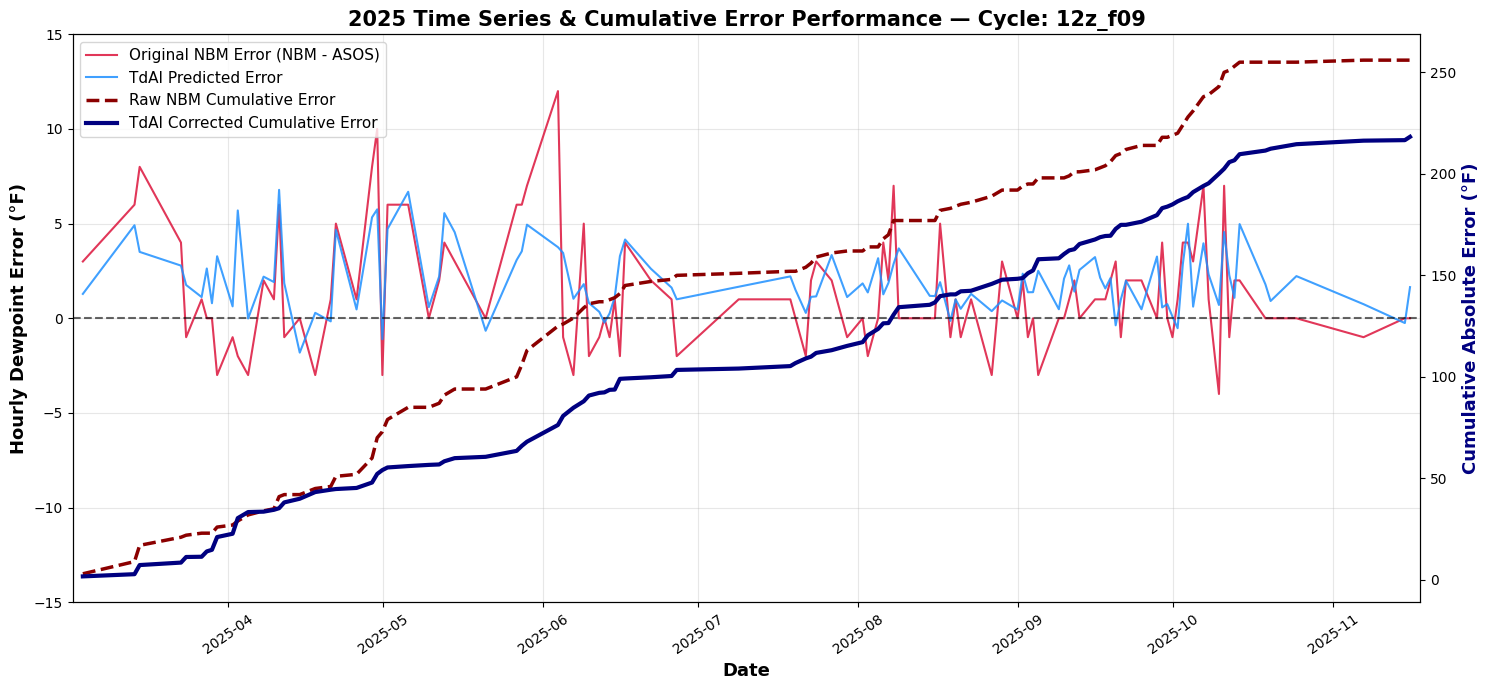


────────────────── Analyzing Cycle: 12z_f33 ──────────────────
📊 Active Operational Samples Evaluated: 115 hours
   • Original NBM Cumulative Error : 309.00°F
   • Corrected Cumulative Error    : 272.08°F
   ───► 🚀 Total Error Removed     : 36.92°F (+11.9% Reduction)


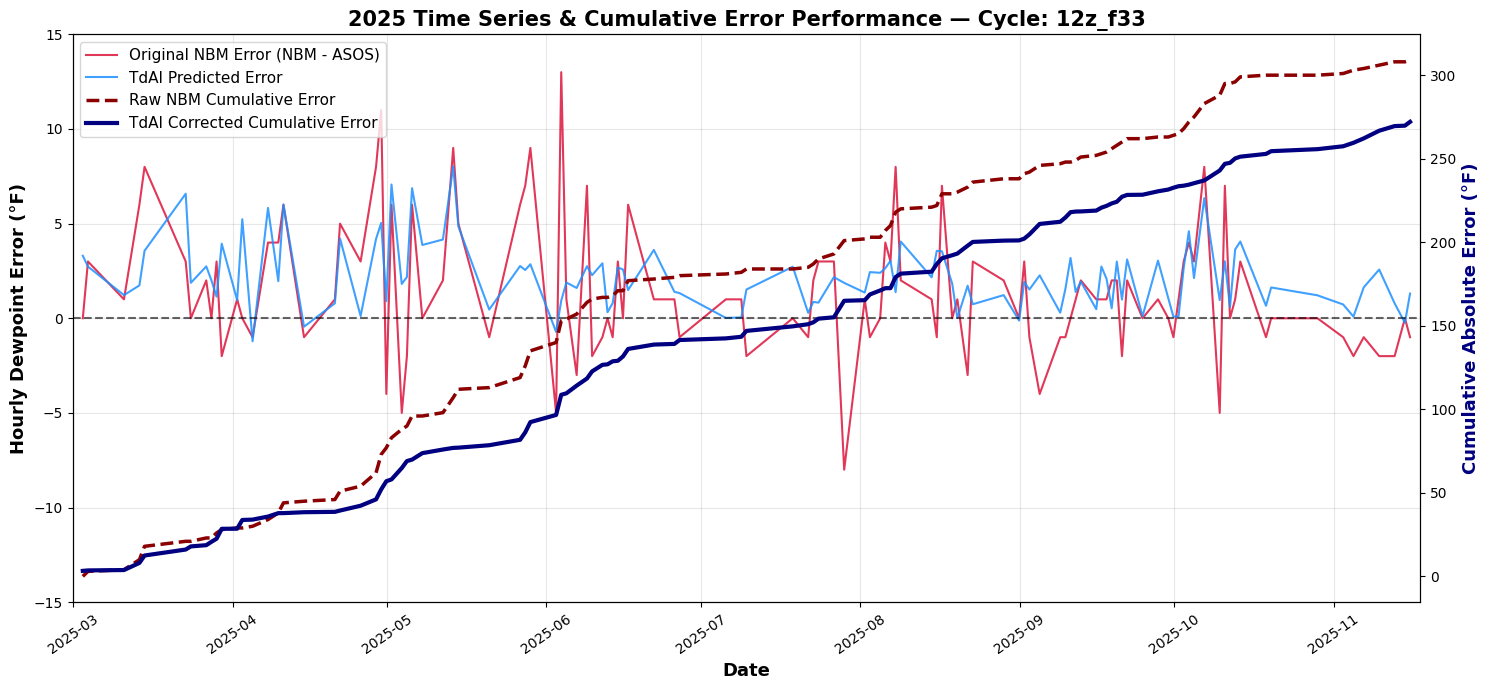


────────────────── Analyzing Cycle: 00z_f21 ──────────────────
📊 Active Operational Samples Evaluated: 112 hours
   • Original NBM Cumulative Error : 287.00°F
   • Corrected Cumulative Error    : 243.85°F
   ───► 🚀 Total Error Removed     : 43.15°F (+15.0% Reduction)


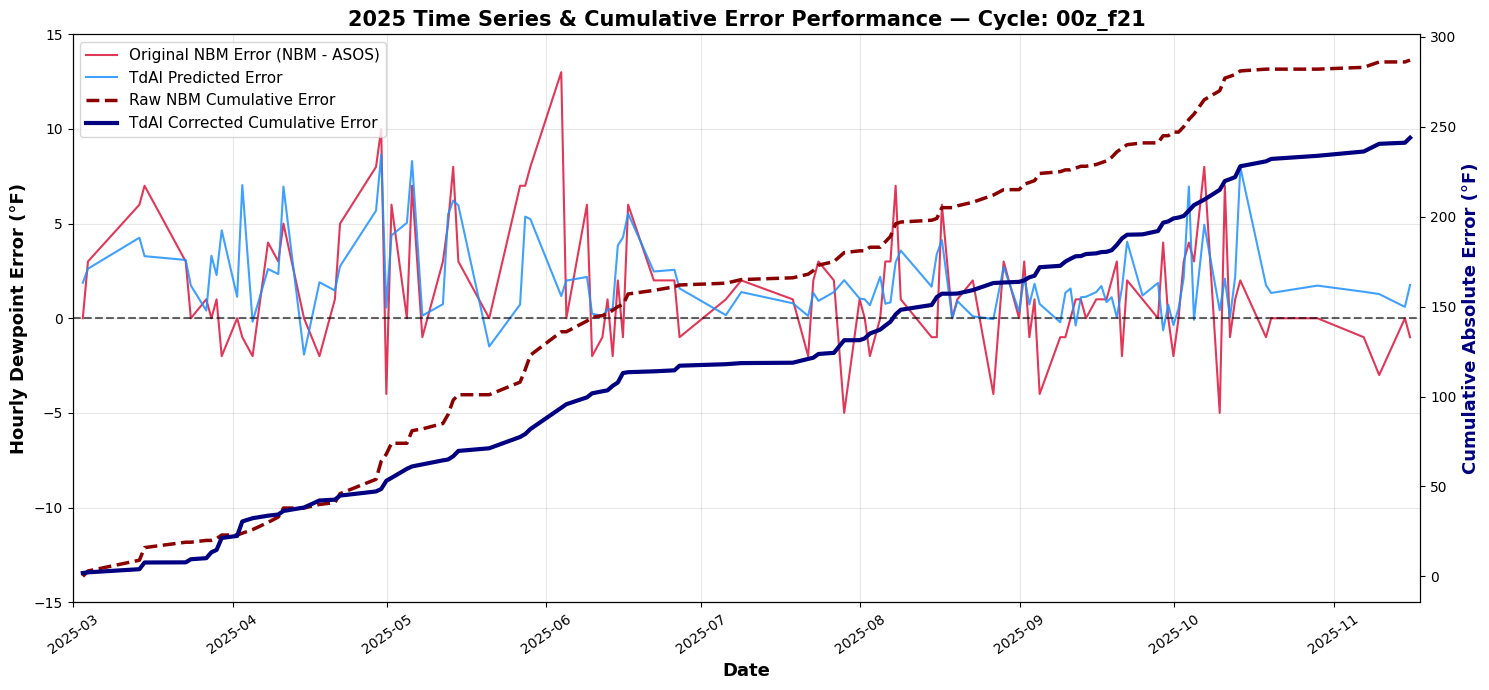


────────────────── Analyzing Cycle: 00z_f45 ──────────────────
📊 Active Operational Samples Evaluated: 119 hours
   • Original NBM Cumulative Error : 357.00°F
   • Corrected Cumulative Error    : 295.39°F
   ───► 🚀 Total Error Removed     : 61.61°F (+17.3% Reduction)


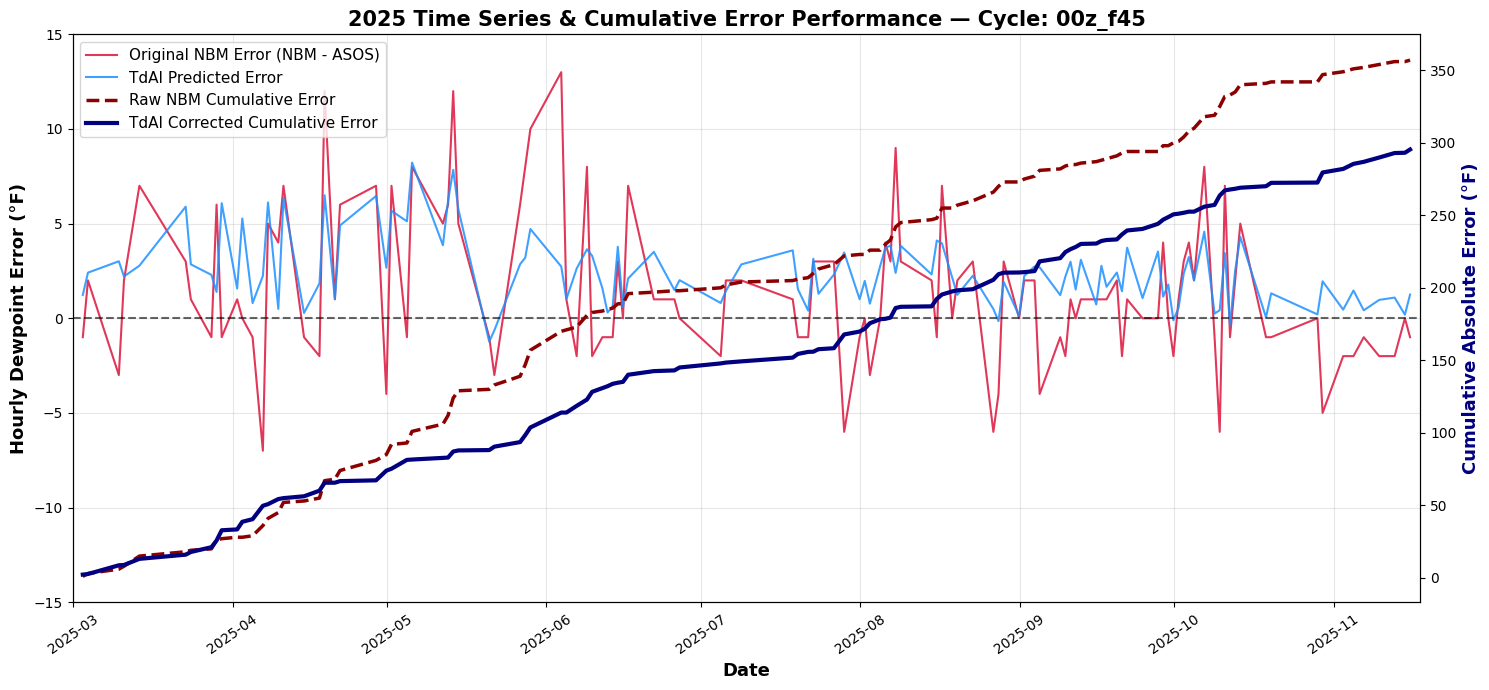


✨ ALL CUMULATIVE ERROR ANALYSES COMPLETE!


In [ ]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
base_path = "/content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/"
models_output_path = os.path.join(base_path, "Trained_TdAI_Models/")

# Define the 4 target operational cycles
CYCLE_NAMES = ['12z_f09', '12z_f33', '00z_f21', '00z_f45']

print("🚀 INITIALIZING MULTI-CYCLE CUMULATIVE ERROR ANALYSIS")
print("=" * 75)

for c_name in CYCLE_NAMES:
    dataset_file = f"TdAI_Training_Data_{c_name}.csv"
    model_file = f"tdai_deterministic_model_{c_name}.joblib"

    dataset_full_path = os.path.join(base_path, f"Training_Dataset/{dataset_file}")
    model_full_path = os.path.join(models_output_path, model_file)

    print(f"\n────────────────── Analyzing Cycle: {c_name} ──────────────────")

    if not (os.path.exists(dataset_full_path) and os.path.exists(model_full_path)):
        print(f"⚠️ Missing dataset ({dataset_file}) or model ({model_file}). Skipping cycle.")
        continue

    # --- 1. LOAD DATASET & TRAINED MODEL ---
    df = pd.read_csv(dataset_full_path)
    if 'valid_time' in df.columns:
        df = df.set_index('valid_time')
    df.index = pd.to_datetime(df.index)

    # Isolate 2025 validation set
    years = df.index.year
    is_test_year = (years == 2025)

    df_test = df[is_test_year].copy()

    if df_test.empty:
        print(f"⚠️ No 2025 validation samples found for cycle {c_name}. Skipping.")
        continue

    X_test = df_test.drop(columns=['Target Error (F)'], errors='ignore')
    y_test = df_test['Target Error (F)']

    # Load trained GBDT model & generate predictions
    gb_model = joblib.load(model_full_path)
    y_pred = gb_model.predict(X_test)

    # --- 2. PREPARE & FILTER RESULTS DATAFRAME ---
    results_df = pd.DataFrame({
        'Valid Time': pd.to_datetime(X_test.index),
        'Actual NBM Error': y_test.values,
        'Model Predicted Error': y_pred
    })

    # Apply Fire Weather Operational Gate Filter
    operational_gate = (
        (X_test['NBM RH (%)'] <= 60.0) &
        (X_test['NBM Cloud Cover (%)'] <= 60.0) &
        (X_test['hrrr_lpw (mm)'] <= 25.0)
    ).values

    results_df = results_df[operational_gate].copy()

    if results_df.empty:
        print(f"⚠️ Zero test samples matched the fire weather operational gate for {c_name}.")
        continue

    # Sort chronologically for smooth time-series plotting
    results_df = results_df.sort_values('Valid Time').reset_index(drop=True)

    # --- 3. CALCULATE CUMULATIVE ABSOLUTE ERRORS ---
    results_df['NBM_Cum_Abs_Error'] = results_df['Actual NBM Error'].abs().cumsum()
    results_df['Residual_Error'] = results_df['Actual NBM Error'] - results_df['Model Predicted Error']
    results_df['Corrected_Cum_Abs_Error'] = results_df['Residual_Error'].abs().cumsum()

    # Metrics Summary
    final_nbm_cum = results_df['NBM_Cum_Abs_Error'].iloc[-1]
    final_corrected_cum = results_df['Corrected_Cum_Abs_Error'].iloc[-1]
    net_improvement = final_nbm_cum - final_corrected_cum
    pct_reduction = (net_improvement / final_nbm_cum) * 100

    print(f"📊 Active Operational Samples Evaluated: {len(results_df)} hours")
    print(f"   • Original NBM Cumulative Error : {final_nbm_cum:.2f}°F")
    print(f"   • Corrected Cumulative Error    : {final_corrected_cum:.2f}°F")
    print(f"   ───► 🚀 Total Error Removed     : {net_improvement:.2f}°F ({pct_reduction:+.1f}% Reduction)")

    # --- 4. PLOTTING ---
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # PRIMARY AXIS: HOURLY ERRORS
    ax1.plot(results_df['Valid Time'], results_df['Actual NBM Error'],
             label='Original NBM Error (NBM - ASOS)', color='crimson', linewidth=1.5, alpha=0.85)

    ax1.plot(results_df['Valid Time'], results_df['Model Predicted Error'],
             label='TdAI Predicted Error', color='dodgerblue', linewidth=1.5, alpha=0.85)

    ax1.axhline(0, color='black', linestyle='--', alpha=0.6)
    ax1.set_ylabel("Hourly Dewpoint Error (°F)", fontsize=13, fontweight='bold')
    ax1.set_xlabel("Date", fontsize=13, fontweight='bold')
    ax1.set_ylim([-15, 15])

    # SECONDARY AXIS: CUMULATIVE RUNNING SUM
    ax2 = ax1.twinx()
    ax2.plot(results_df['Valid Time'], results_df['NBM_Cum_Abs_Error'],
             label='Raw NBM Cumulative Error', color='darkred', linestyle='--', linewidth=2.5)

    ax2.plot(results_df['Valid Time'], results_df['Corrected_Cum_Abs_Error'],
             label='TdAI Corrected Cumulative Error', color='navy', linewidth=3.0)

    ax2.set_ylabel("Cumulative Absolute Error (°F)", fontsize=13, color='navy', fontweight='bold')

    # Formatting and Layout
    ax1.grid(alpha=0.3)
    ax1.tick_params(axis='x', labelrotation=35)
    plt.title(f"2025 Time Series & Cumulative Error Performance — Cycle: {c_name}", fontsize=15, fontweight='bold')

    # Combine Legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

    # Dynamic x-axis zoom based on actual available data bounds
    min_date = results_df['Valid Time'].min() - pd.Timedelta(days=2)
    max_date = results_df['Valid Time'].max() + pd.Timedelta(days=2)
    ax1.set_xlim(min_date, max_date)

    plt.tight_layout()
    plt.show()

print("\n✨ ALL CUMULATIVE ERROR ANALYSES COMPLETE!")

🚀 INITIALIZING MULTI-CYCLE BUST DIRECTIONAL ACCURACY ANALYSIS

────────────────── Analyzing Cycle: 12z_f09 ──────────────────
📊 Results Summary for 12z_f09:
   • Global 2025 Directional Accuracy     : 56.25% (n=256)
   • Tactical Fire Weather Window Accuracy: 53.15% (n=111)

────────────────── Analyzing Cycle: 12z_f33 ──────────────────
📊 Results Summary for 12z_f33:
   • Global 2025 Directional Accuracy     : 60.47% (n=253)
   • Tactical Fire Weather Window Accuracy: 58.26% (n=115)

────────────────── Analyzing Cycle: 00z_f21 ──────────────────
📊 Results Summary for 00z_f21:
   • Global 2025 Directional Accuracy     : 59.84% (n=254)
   • Tactical Fire Weather Window Accuracy: 57.14% (n=112)

────────────────── Analyzing Cycle: 00z_f45 ──────────────────
📊 Results Summary for 00z_f45:
   • Global 2025 Directional Accuracy     : 60.63% (n=254)
   • Tactical Fire Weather Window Accuracy: 57.14% (n=119)


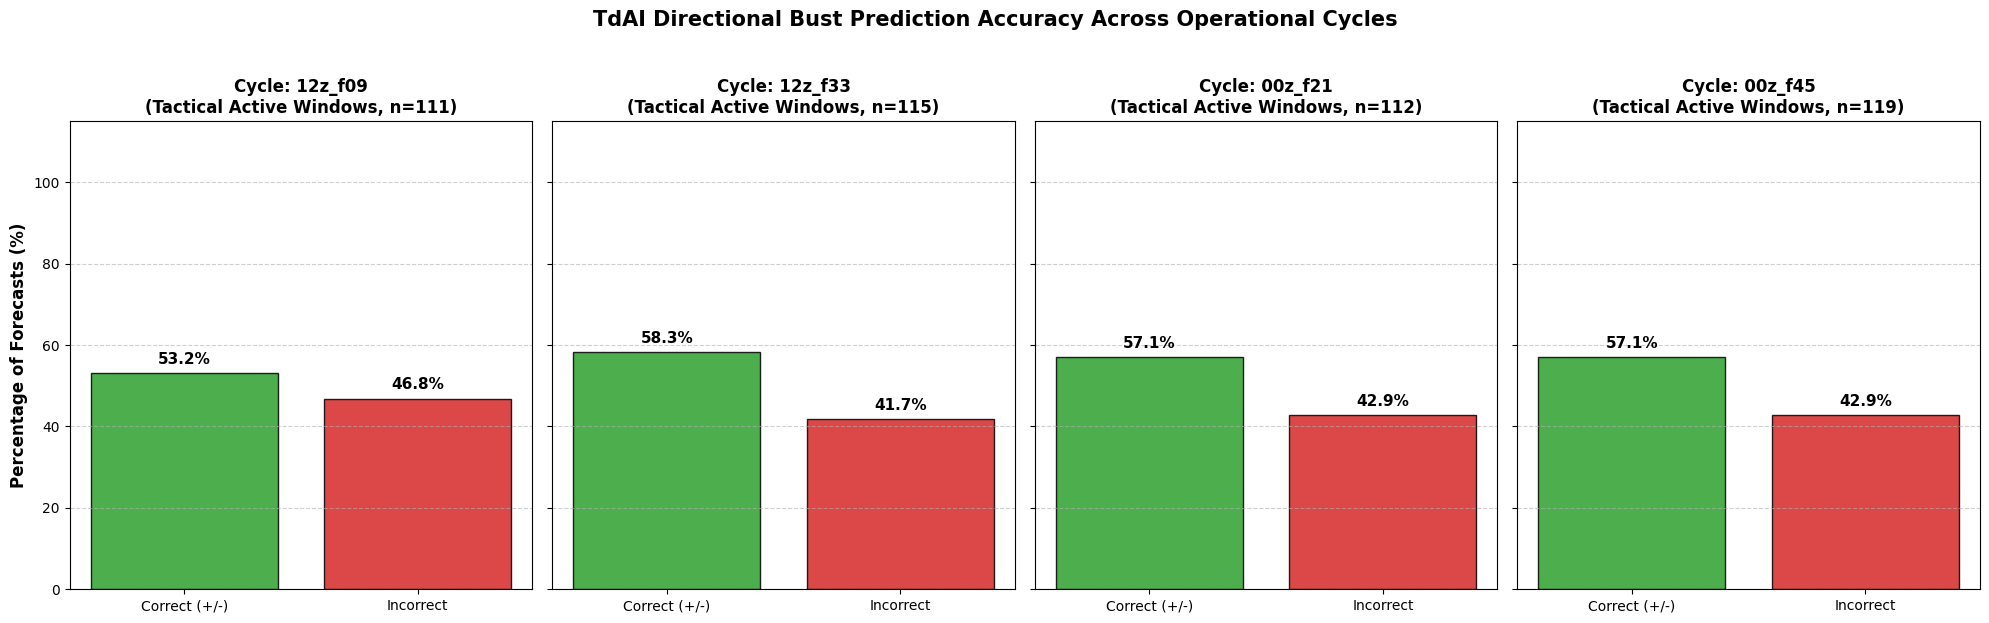


✨ ALL DIRECTIONAL BUST ACCURACY ANALYSES COMPLETE!


In [ ]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
base_path = "/content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/"
models_output_path = os.path.join(base_path, "Trained_TdAI_Models/")

# Define the 4 target operational cycles
CYCLE_NAMES = ['12z_f09', '12z_f33', '00z_f21', '00z_f45']

print("🚀 INITIALIZING MULTI-CYCLE BUST DIRECTIONAL ACCURACY ANALYSIS")
print("=" * 75)

# Dictionary to store cycle accuracy results for multi-panel plotting
cycle_accuracy_results = {}

for c_name in CYCLE_NAMES:
    dataset_file = f"TdAI_Training_Data_{c_name}.csv"
    model_file = f"tdai_deterministic_model_{c_name}.joblib"

    dataset_full_path = os.path.join(base_path, f"Training_Dataset/{dataset_file}")
    model_full_path = os.path.join(models_output_path, model_file)

    print(f"\n────────────────── Analyzing Cycle: {c_name} ──────────────────")

    if not (os.path.exists(dataset_full_path) and os.path.exists(model_full_path)):
        print(f"⚠️ Missing dataset ({dataset_file}) or model ({model_file}). Skipping cycle.")
        continue

    # --- 1. LOAD DATASET & TRAINED MODEL ---
    df = pd.read_csv(dataset_full_path)
    if 'valid_time' in df.columns:
        df = df.set_index('valid_time')
    df.index = pd.to_datetime(df.index)

    # Isolate 2025 validation set
    years = df.index.year
    is_test_year = (years == 2025)

    df_test = df[is_test_year].copy()

    if df_test.empty:
        print(f"⚠️ No 2025 validation samples found for cycle {c_name}. Skipping.")
        continue

    X_test = df_test.drop(columns=['Target Error (F)'], errors='ignore')
    y_test = df_test['Target Error (F)']

    # Load trained GBDT model & generate predictions
    gb_model = joblib.load(model_full_path)
    y_pred = gb_model.predict(X_test)

    # --- 2. GLOBAL DIRECTIONAL ACCURACY (ALL 2025 HOURS) ---
    actual_sign_global = np.sign(y_test)
    predicted_sign_global = np.sign(y_pred)
    correct_dir_global = (actual_sign_global == predicted_sign_global)
    global_accuracy_pct = correct_dir_global.mean() * 100

    # --- 3. ACTIVE FIRE WEATHER DOMAIN DIRECTIONAL ACCURACY ---
    operational_gate = (
        (X_test['NBM RH (%)'] <= 60.0) &
        (X_test['NBM Cloud Cover (%)'] <= 60.0) &
        (X_test['hrrr_lpw (mm)'] <= 25.0)
    ).values

    X_test_active = X_test[operational_gate]
    y_test_active = y_test[operational_gate]
    y_pred_active = y_pred[operational_gate]

    if len(X_test_active) > 0:
        actual_sign_active = np.sign(y_test_active)
        predicted_sign_active = np.sign(y_pred_active)
        correct_dir_active = (actual_sign_active == predicted_sign_active)
        active_accuracy_pct = correct_dir_active.mean() * 100
    else:
        active_accuracy_pct = np.nan

    # Store metrics for plotting
    cycle_accuracy_results[c_name] = {
        'global_accuracy': global_accuracy_pct,
        'global_n': len(y_test),
        'active_accuracy': active_accuracy_pct,
        'active_n': len(y_test_active)
    }

    print(f"📊 Results Summary for {c_name}:")
    print(f"   • Global 2025 Directional Accuracy     : {global_accuracy_pct:.2f}% (n={len(y_test)})")
    if not np.isnan(active_accuracy_pct):
        print(f"   • Tactical Fire Weather Window Accuracy: {active_accuracy_pct:.2f}% (n={len(y_test_active)})")

# --- 4. MULTI-PANEL VISUALIZATION FOR ALL AVAILABLE CYCLES ---
if cycle_accuracy_results:
    valid_cycles = list(cycle_accuracy_results.keys())
    num_cycles = len(valid_cycles)

    fig, axes = plt.subplots(1, num_cycles, figsize=(5 * num_cycles, 6), sharey=True)
    if num_cycles == 1:
        axes = [axes]

    categories = ['Correct (+/-)', 'Incorrect']
    colors = ['#2ca02c', '#d62728']  # Green and Red

    for ax, c_name in zip(axes, valid_cycles):
        metrics = cycle_accuracy_results[c_name]

        # Use active fire weather accuracy if available, else fall back to global
        acc_pct = metrics['active_accuracy'] if not np.isnan(metrics['active_accuracy']) else metrics['global_accuracy']
        n_count = metrics['active_n'] if not np.isnan(metrics['active_accuracy']) else metrics['global_n']
        context_str = "Tactical Active Windows" if not np.isnan(metrics['active_accuracy']) else "Global 2025"

        values = [acc_pct, 100.0 - acc_pct]
        bars = ax.bar(categories, values, color=colors, alpha=0.85, edgecolor='black', linewidth=1)

        # Add percentage labels on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 1.5,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

        ax.set_title(f"Cycle: {c_name}\n({context_str}, n={n_count})", fontsize=12, fontweight='bold')
        ax.set_ylim(0, 115)
        ax.grid(axis='y', linestyle='--', alpha=0.6)

    axes[0].set_ylabel("Percentage of Forecasts (%)", fontsize=12, fontweight='bold')
    plt.suptitle("TdAI Directional Bust Prediction Accuracy Across Operational Cycles", fontsize=15, fontweight='bold', y=1.03)

    plt.tight_layout()
    plt.show()

print("\n✨ ALL DIRECTIONAL BUST ACCURACY ANALYSES COMPLETE!")

🚀 INITIALIZING MULTI-CYCLE PERMUTATION FEATURE IMPORTANCE ANALYSIS

────────────────── Analyzing Cycle: 12z_f09 ──────────────────
   ⚙️ Calculating Permutation Importance (Fire Weather Filter (n=111))...
   📊 Top 5 Key Predictors for 12z_f09:
      • sin_season                         : 0.2500 MAE increase when shuffled
      • rh_850                             : 0.1994 MAE increase when shuffled
      • rh_825                             : 0.0665 MAE increase when shuffled
      • rh_750                             : 0.0560 MAE increase when shuffled
      • rh_775                             : 0.0359 MAE increase when shuffled


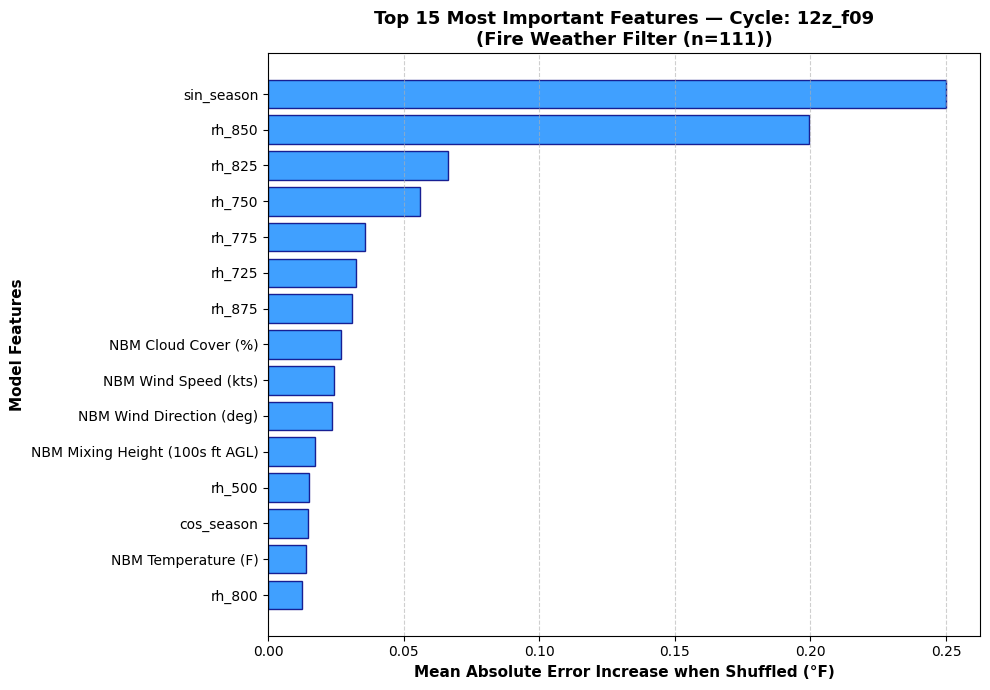


────────────────── Analyzing Cycle: 12z_f33 ──────────────────
   ⚙️ Calculating Permutation Importance (Fire Weather Filter (n=115))...
   📊 Top 5 Key Predictors for 12z_f33:
      • sin_season                         : 0.3859 MAE increase when shuffled
      • rh_900                             : 0.2088 MAE increase when shuffled
      • 1000mb-700mb Lapse Rate (C/km)     : 0.0448 MAE increase when shuffled
      • rh_875                             : 0.0393 MAE increase when shuffled
      • rh_825                             : 0.0385 MAE increase when shuffled


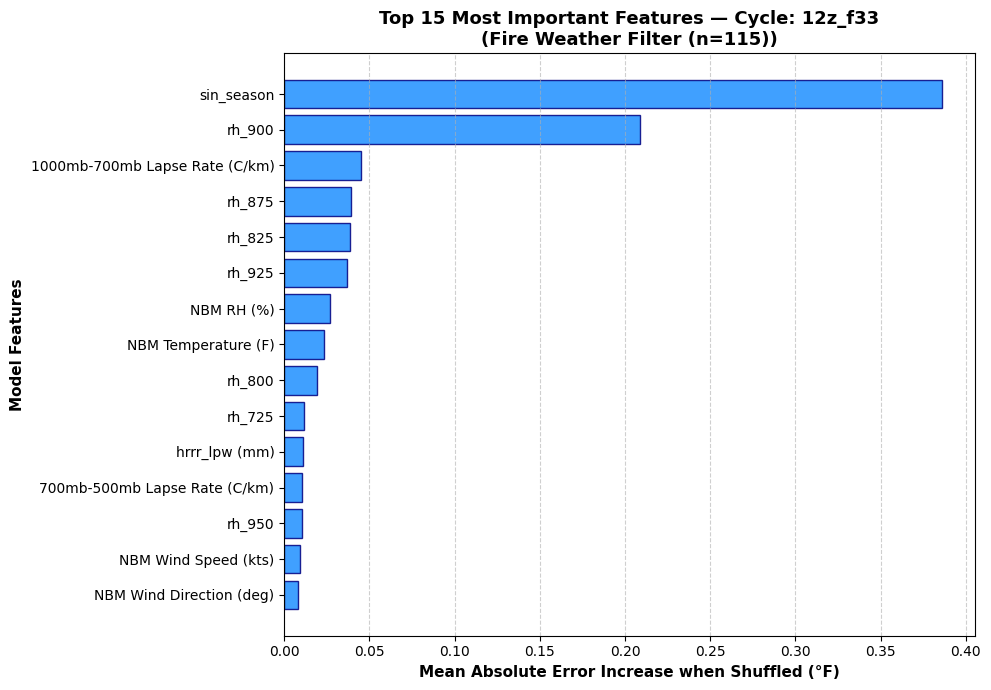


────────────────── Analyzing Cycle: 00z_f21 ──────────────────
   ⚙️ Calculating Permutation Importance (Fire Weather Filter (n=112))...
   📊 Top 5 Key Predictors for 00z_f21:
      • sin_season                         : 0.2879 MAE increase when shuffled
      • rh_875                             : 0.1250 MAE increase when shuffled
      • rh_900                             : 0.1250 MAE increase when shuffled
      • 1000mb-700mb Lapse Rate (C/km)     : 0.0438 MAE increase when shuffled
      • NBM Wind Speed (kts)               : 0.0381 MAE increase when shuffled


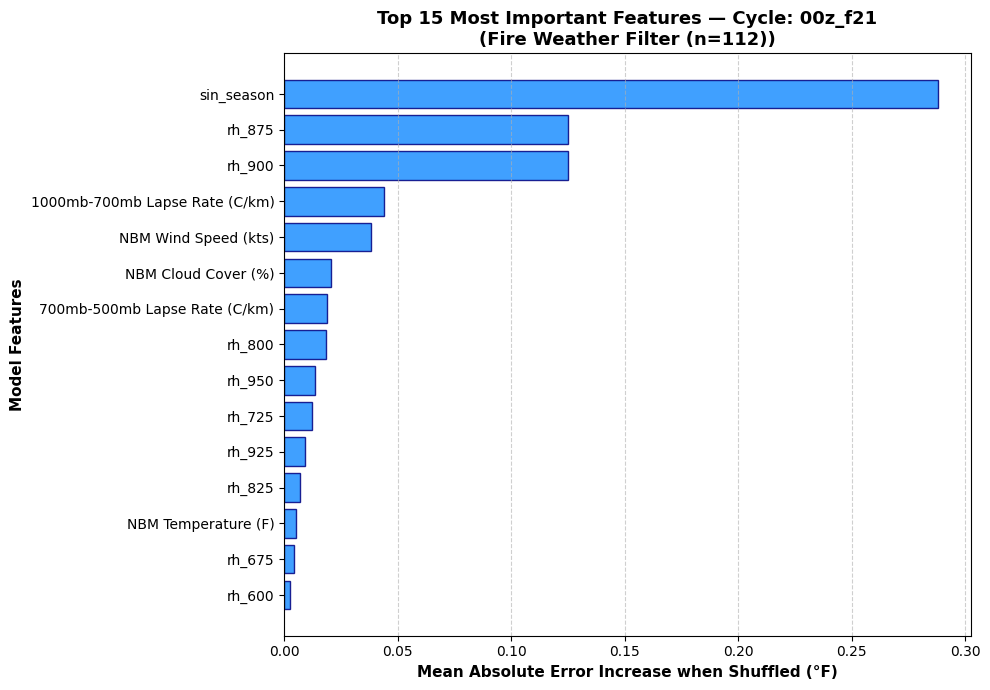


────────────────── Analyzing Cycle: 00z_f45 ──────────────────
   ⚙️ Calculating Permutation Importance (Fire Weather Filter (n=119))...
   📊 Top 5 Key Predictors for 00z_f45:
      • sin_season                         : 0.5292 MAE increase when shuffled
      • rh_925                             : 0.3431 MAE increase when shuffled
      • rh_875                             : 0.1683 MAE increase when shuffled
      • 1000mb-700mb Lapse Rate (C/km)     : 0.0832 MAE increase when shuffled
      • rh_900                             : 0.0659 MAE increase when shuffled


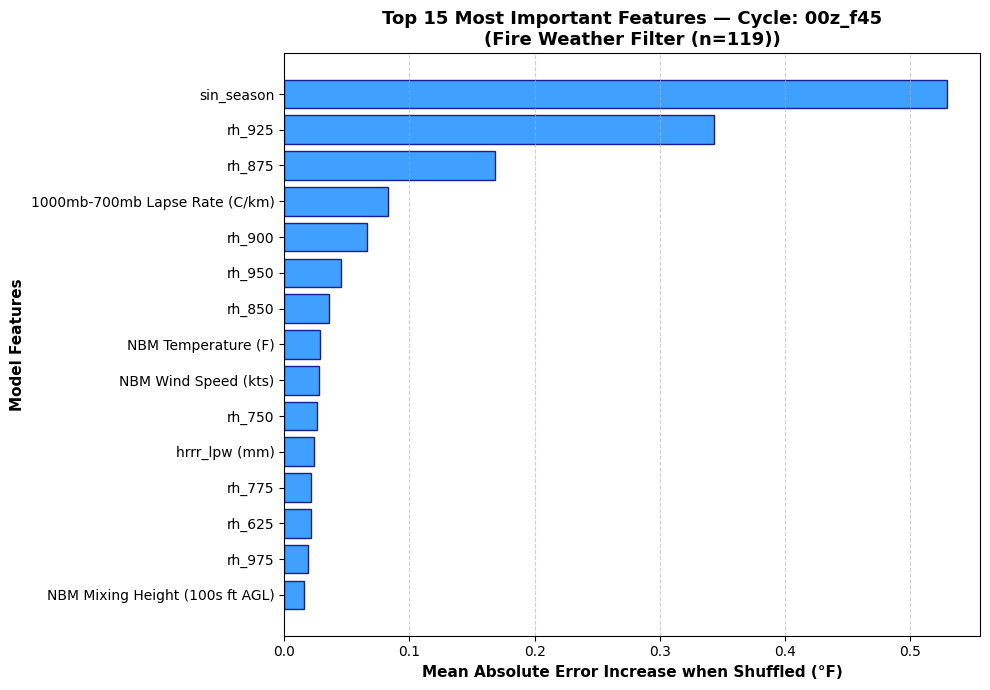


✨ ALL FEATURE IMPORTANCE ANALYSES COMPLETE!


In [ ]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# --- CONFIGURATION ---
base_path = "/content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/"
models_output_path = os.path.join(base_path, "Trained_TdAI_Models/")

# Define the 4 target operational cycles
CYCLE_NAMES = ['12z_f09', '12z_f33', '00z_f21', '00z_f45']

print("🚀 INITIALIZING MULTI-CYCLE PERMUTATION FEATURE IMPORTANCE ANALYSIS")
print("=" * 75)

for c_name in CYCLE_NAMES:
    dataset_file = f"TdAI_Training_Data_{c_name}.csv"
    model_file = f"tdai_deterministic_model_{c_name}.joblib"

    dataset_full_path = os.path.join(base_path, f"Training_Dataset/{dataset_file}")
    model_full_path = os.path.join(models_output_path, model_file)

    print(f"\n────────────────── Analyzing Cycle: {c_name} ──────────────────")

    if not (os.path.exists(dataset_full_path) and os.path.exists(model_full_path)):
        print(f"⚠️ Missing dataset ({dataset_file}) or model ({model_file}). Skipping cycle.")
        continue

    # --- 1. LOAD DATASET & TRAINED MODEL ---
    df = pd.read_csv(dataset_full_path)
    if 'valid_time' in df.columns:
        df = df.set_index('valid_time')
    df.index = pd.to_datetime(df.index)

    # Isolate 2025 validation set
    years = df.index.year
    is_test_year = (years == 2025)

    df_test = df[is_test_year].copy()

    if df_test.empty:
        print(f"⚠️ No 2025 validation samples found for cycle {c_name}. Skipping.")
        continue

    X_test = df_test.drop(columns=['Target Error (F)'], errors='ignore')
    y_test = df_test['Target Error (F)']

    # Load trained GBDT model
    gb_model = joblib.load(model_full_path)

    # --- 2. FILTER FOR ACTIVE FIRE WEATHER DOMAIN WINDOWS ---
    operational_gate = (
        (X_test['NBM RH (%)'] <= 60.0) &
        (X_test['NBM Cloud Cover (%)'] <= 60.0) &
        (X_test['hrrr_lpw (mm)'] <= 25.0)
    ).values

    X_test_active = X_test[operational_gate]
    y_test_active = y_test[operational_gate]

    # Fallback to full test set if active set is empty
    if len(X_test_active) > 0:
        X_eval, y_eval = X_test_active, y_test_active
        eval_context = f"Fire Weather Filter (n={len(X_eval)})"
    else:
        X_eval, y_eval = X_test, y_test
        eval_context = f"Global 2025 Test Set (n={len(X_eval)})"

    # --- 3. CALCULATE PERMUTATION IMPORTANCE ---
    print(f"   ⚙️ Calculating Permutation Importance ({eval_context})...")
    result = permutation_importance(
        gb_model,
        X_eval,
        y_eval,
        n_repeats=10,
        scoring='neg_mean_absolute_error',
        random_state=42
    )

    # Organize feature importances into a Series
    importances = pd.Series(result.importances_mean, index=X_eval.columns).sort_values(ascending=False)

    print(f"   📊 Top 5 Key Predictors for {c_name}:")
    for feat, val in importances.head(5).items():
        print(f"      • {feat:35s}: {val:.4f} MAE increase when shuffled")

    # --- 4. GENERATE FEATURE IMPORTANCE PLOT ---
    plt.figure(figsize=(10, 7))

    top_n = min(15, len(importances))
    top_importances = importances.head(top_n).sort_values(ascending=True) # Ascending for horizontal bar plot

    plt.barh(top_importances.index, top_importances.values, color='dodgerblue', edgecolor='navy', alpha=0.85)
    plt.title(f"Top {top_n} Most Important Features — Cycle: {c_name}\n({eval_context})", fontsize=13, fontweight='bold')
    plt.xlabel("Mean Absolute Error Increase when Shuffled (°F)", fontsize=11, fontweight='bold')
    plt.ylabel("Model Features", fontsize=11, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 75)
print("✨ ALL FEATURE IMPORTANCE ANALYSES COMPLETE!")

🚀 INITIALIZING MULTI-CYCLE SHAP EXPLAINER PIPELINE

────────────────── Generating SHAP Explainer: 12z_f09 ──────────────────
   📊 Computing SHAP Values for 12z_f09 (Tactical Active Fire Weather Windows (n=111))...


PermutationExplainer explainer: 112it [03:15,  1.81s/it]


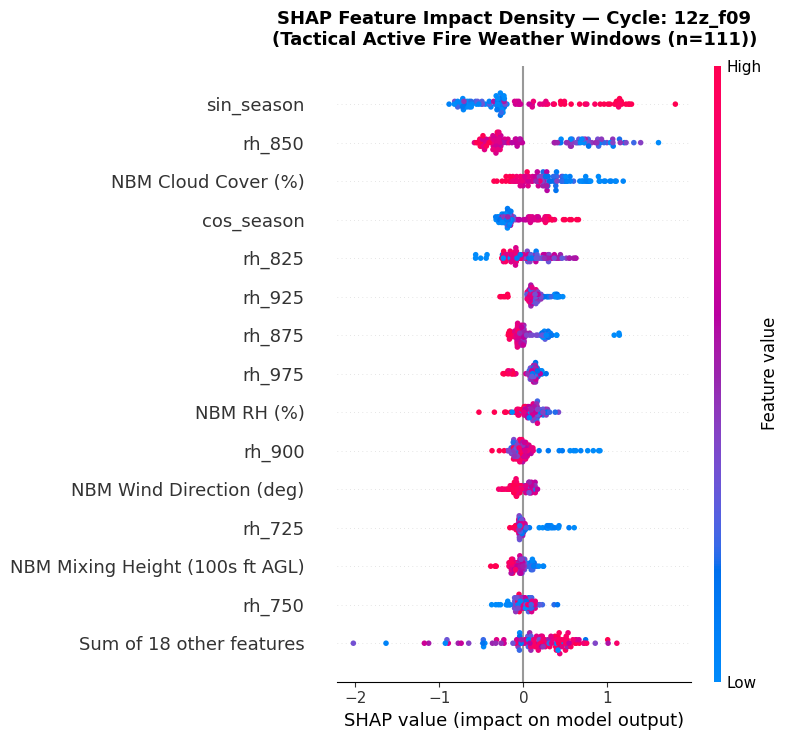

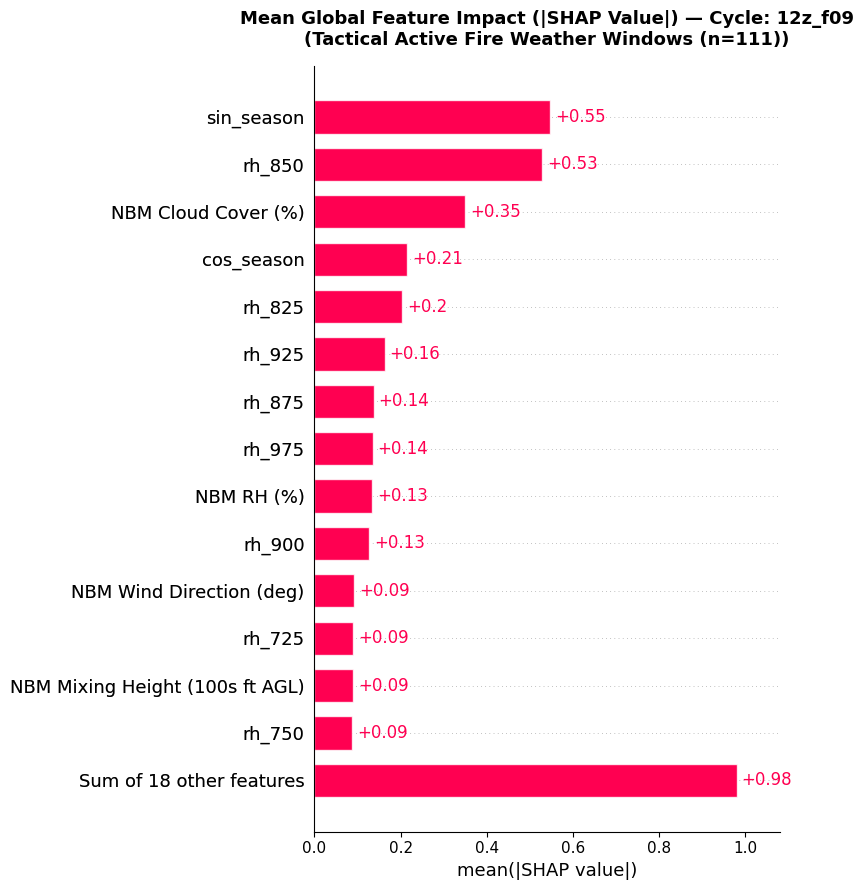


────────────────── Generating SHAP Explainer: 12z_f33 ──────────────────
   📊 Computing SHAP Values for 12z_f33 (Tactical Active Fire Weather Windows (n=115))...


PermutationExplainer explainer: 116it [03:17,  1.80s/it]


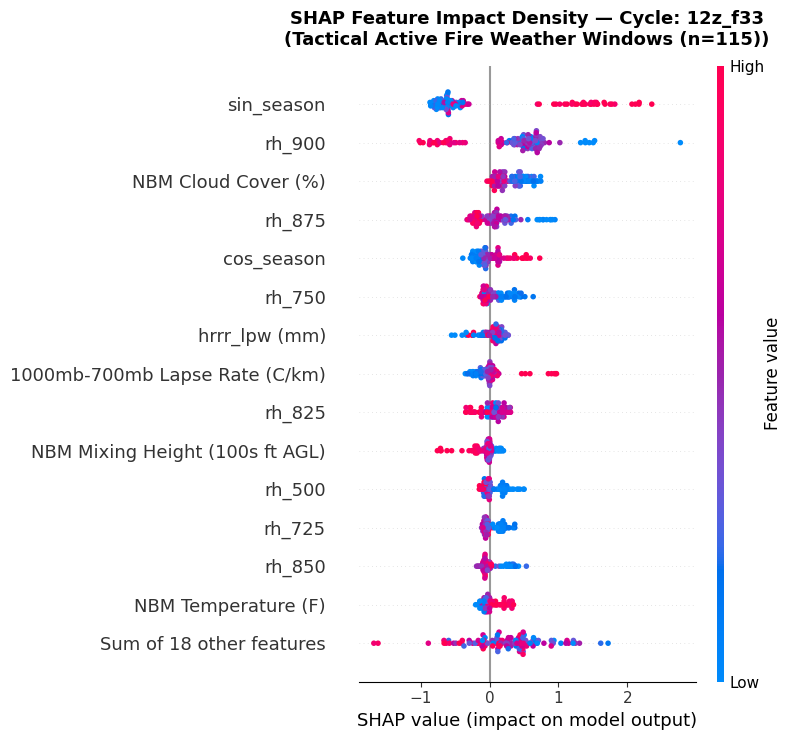

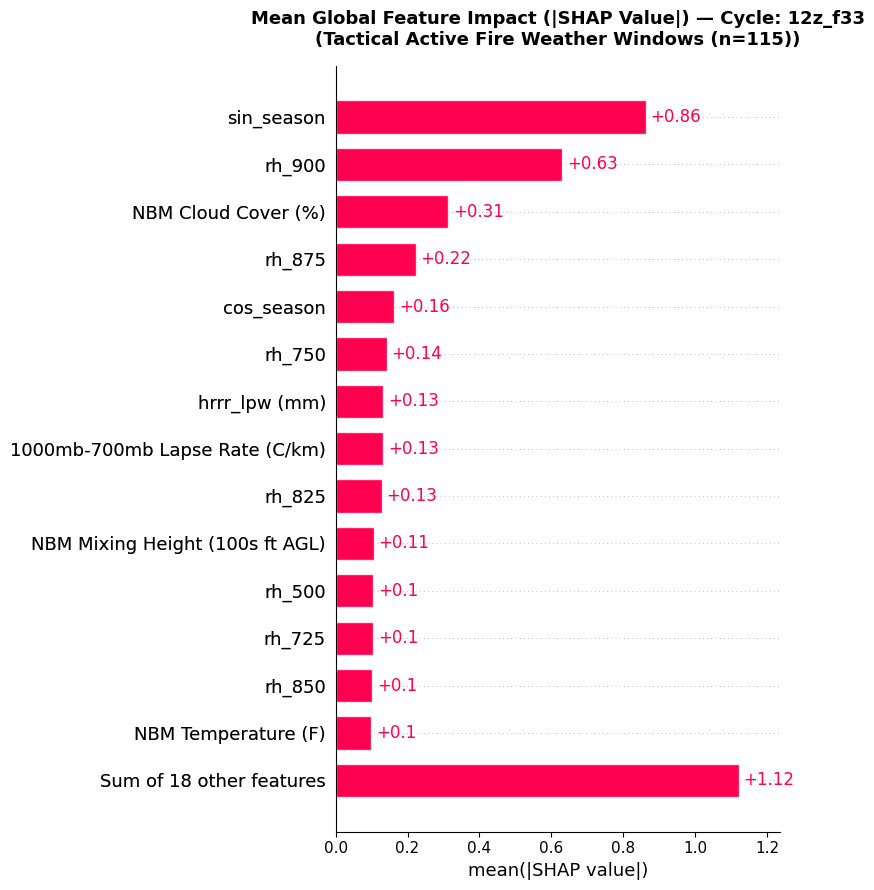


────────────────── Generating SHAP Explainer: 00z_f21 ──────────────────
   📊 Computing SHAP Values for 00z_f21 (Tactical Active Fire Weather Windows (n=112))...


PermutationExplainer explainer: 113it [03:12,  1.79s/it]


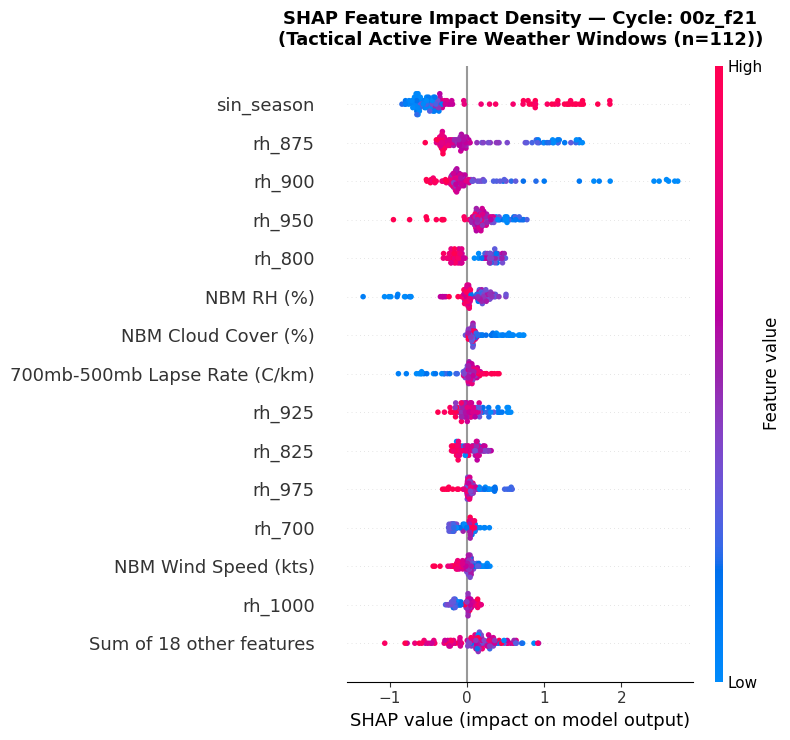

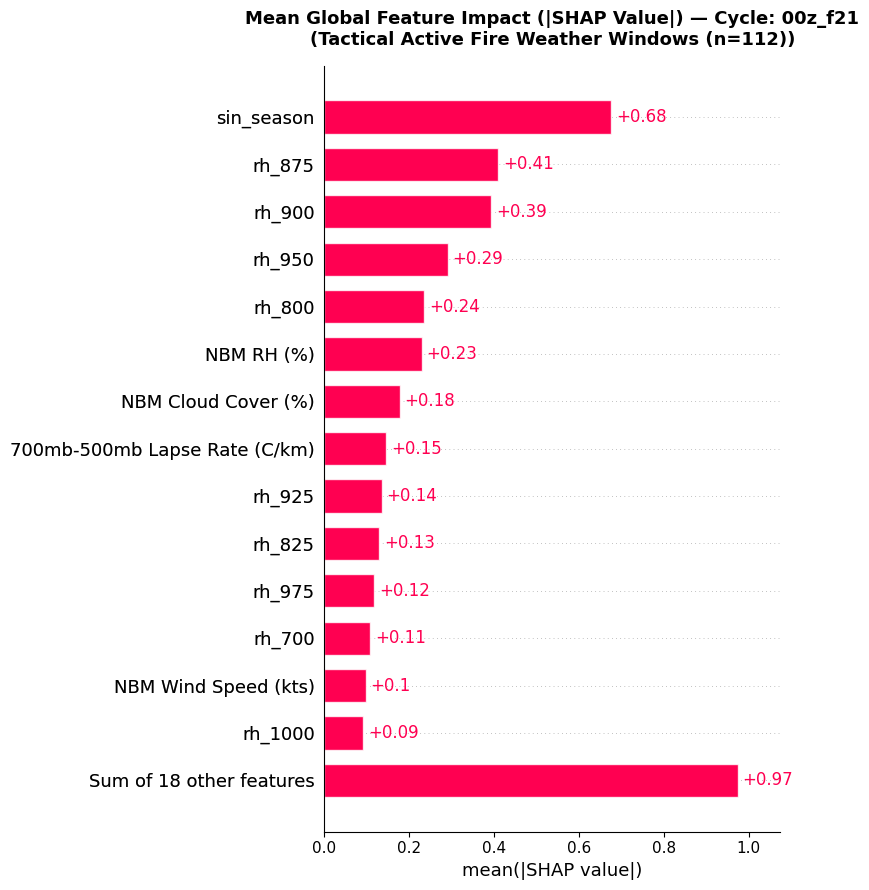


────────────────── Generating SHAP Explainer: 00z_f45 ──────────────────
   📊 Computing SHAP Values for 00z_f45 (Tactical Active Fire Weather Windows (n=119))...


PermutationExplainer explainer: 120it [03:24,  1.80s/it]


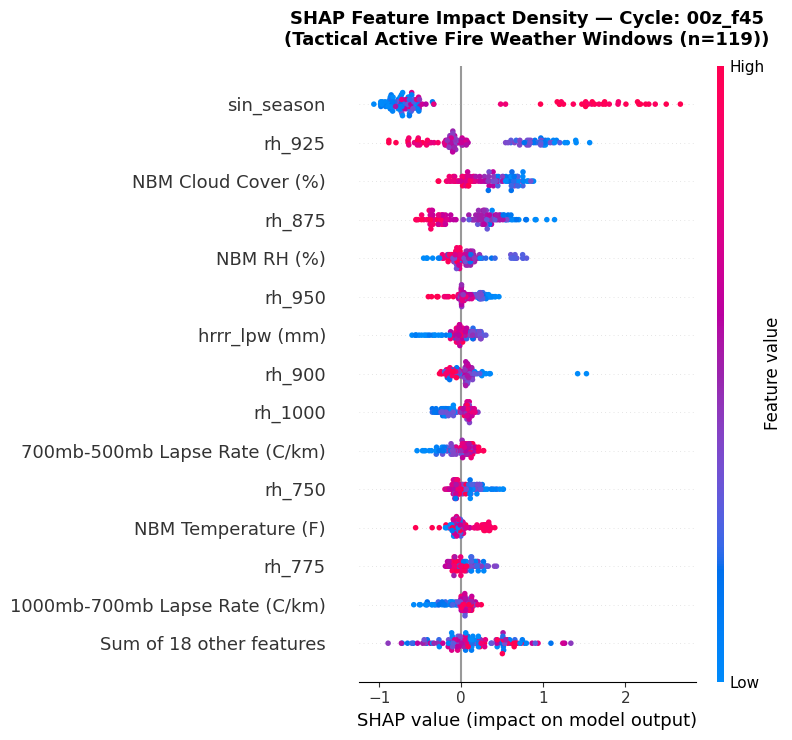

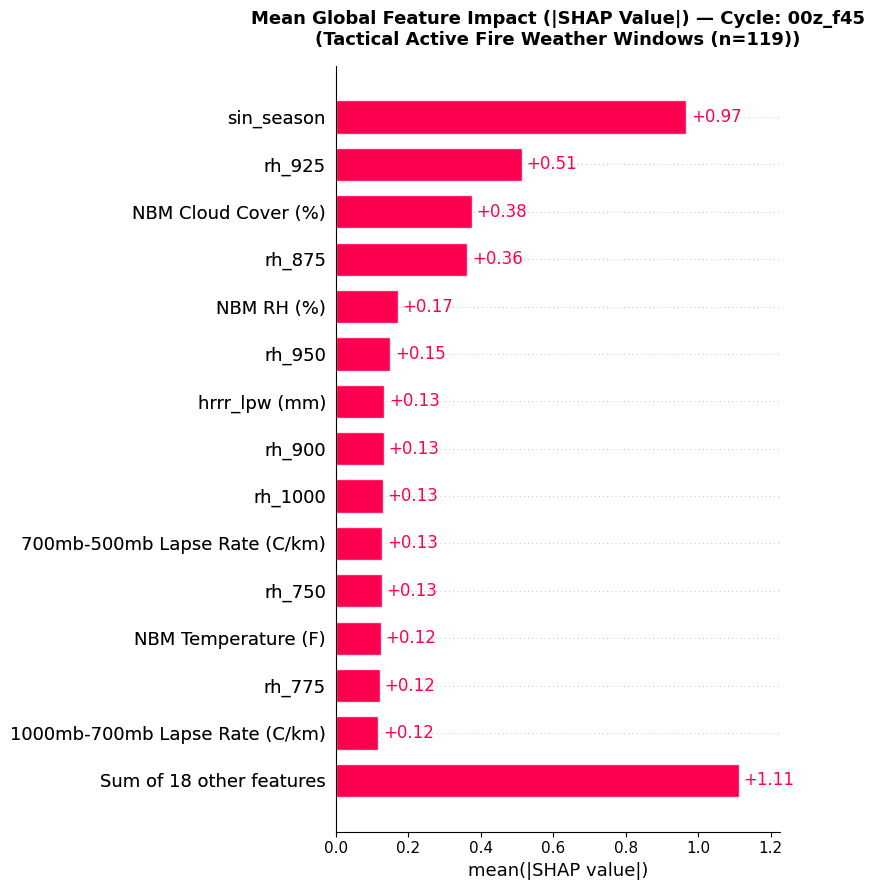


✨ ALL SHAP EXPLAINER ANALYSES COMPLETE!


In [ ]:
# --- CONFIGURATION ---
base_path = "/content/drive/MyDrive/Fire Weather Focal Point/TdAI_Project/Development/Data/"
models_output_path = os.path.join(base_path, "Trained_TdAI_Models/")

# Define the 4 target operational cycles
CYCLE_NAMES = ['12z_f09', '12z_f33', '00z_f21', '00z_f45']

print("🚀 INITIALIZING MULTI-CYCLE SHAP EXPLAINER PIPELINE")
print("=" * 75)

for c_name in CYCLE_NAMES:
    dataset_file = f"TdAI_Training_Data_{c_name}.csv"
    model_file = f"tdai_deterministic_model_{c_name}.joblib"

    dataset_full_path = os.path.join(base_path, f"Training_Dataset/{dataset_file}")
    model_full_path = os.path.join(models_output_path, model_file)

    print(f"\n────────────────── Generating SHAP Explainer: {c_name} ──────────────────")

    if not (os.path.exists(dataset_full_path) and os.path.exists(model_full_path)):
        print(f"⚠️ Missing dataset ({dataset_file}) or model ({model_file}). Skipping cycle.")
        continue

    # --- 1. LOAD DATASET & TRAINED MODEL ---
    df = pd.read_csv(dataset_full_path)
    if 'valid_time' in df.columns:
        df = df.set_index('valid_time')
    df.index = pd.to_datetime(df.index)

    # Isolate 2025 validation set
    years = df.index.year
    is_test_year = (years == 2025)

    df_test = df[is_test_year].copy()

    if df_test.empty:
        print(f"⚠️ No 2025 validation samples found for cycle {c_name}. Skipping.")
        continue

    X_test = df_test.drop(columns=['Target Error (F)'], errors='ignore')

    # Load trained GBDT model
    gb_model = joblib.load(model_full_path)

    # --- 2. FILTER FOR ACTIVE TACTICAL FIRE WEATHER DOMAIN WINDOWS ---
    operational_gate = (
        (X_test['NBM RH (%)'] <= 60.0) &
        (X_test['NBM Cloud Cover (%)'] <= 60.0) &
        (X_test['hrrr_lpw (mm)'] <= 25.0)
    ).values

    X_test_active = X_test[operational_gate].copy()

    # Fallback to full test set if active window is empty
    if len(X_test_active) > 0:
        X_eval = X_test_active
        eval_context = f"Tactical Active Fire Weather Windows (n={len(X_eval)})"
    else:
        X_eval = X_test
        eval_context = f"Global 2025 Test Set (n={len(X_eval)})"

    print(f"   📊 Computing SHAP Values for {c_name} ({eval_context})...")

    # --- 3. CREATE SHAP EXPLAINER ---
    # Sample background reference dataset for model expectation (optimizes speed & memory)
    background_summary = shap.sample(X_test, min(100, len(X_test)), random_state=42)

    # Initialize Model Explainer on model prediction function
    explainer = shap.Explainer(gb_model.predict, background_summary)

    # Calculate SHAP explanation values for active test hours
    shap_values = explainer(X_eval)

    # --- 4. VISUALIZATION 1: SHAP BEESWARM SUMMARY PLOT ---
    # Shows feature magnitude (color) vs. direction/impact on predicted error (+/- °F)
    plt.figure(figsize=(10, 7))
    plt.title(f"SHAP Feature Impact Density — Cycle: {c_name}\n({eval_context})", fontsize=13, fontweight='bold', pad=15)
    shap.plots.beeswarm(shap_values, max_display=15, show=False)
    plt.tight_layout()
    plt.show()

    # --- 5. VISUALIZATION 2: MEAN GLOBAL FEATURE IMPACT BAR PLOT ---
    # Shows overall average feature contribution magnitude (|SHAP Value|)
    plt.figure(figsize=(10, 6))
    plt.title(f"Mean Global Feature Impact (|SHAP Value|) — Cycle: {c_name}\n({eval_context})", fontsize=13, fontweight='bold', pad=15)
    shap.plots.bar(shap_values, max_display=15, show=False)
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 75)
print("✨ ALL SHAP EXPLAINER ANALYSES COMPLETE!")